# Modelado del precio — Airbnb Nueva York

Este notebook predice `log(price)` de un anuncio de Nueva York con la información disponible al publicarlo,
subiendo de los modelos más simples a los más complejos. La hoja de ruta completa, con las alternativas
descartadas, está en `docs/plan_modelado.md`, y cada decisión, en `docs/bitacora_decisiones.md`.

**Parte de:** `data/modelado/train.parquet` y `data/modelado/preparador.json` (de ahí salen los bloques de variables), que genera
`preparacion_datos.py`. El preparador (ventana de amenities, tipos de propiedad frecuentes, medianas de
`bedrooms`) se ajusta **solo con el train**. 

**Decisiones de partida:**

- Definimos dos escenarios: **escenario A** (anfitrión nuevo, sin perfil) como contraste y **Escenario B** (anuncio nuevo de cualquier anfitrión, con su perfil) como modelo principal;. 
- **Test del 20%**, agrupado por `host_id` y estratificado por `room_type` × `district`.
- **CV de 5 folds × 3 repeticiones** para seleccionar variables, y 5 folds para comparar modelos y ajustar hiperparámetros, con el mismo estrato que el test.

**Fase 1 (este bloque):** carga del train, particiones de validación y funciones de evaluación y registro.
Las funciones están en `func_modelado.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr
from IPython.display import display
from pathlib import Path
from sklearn.dummy import DummyRegressor
import warnings
warnings.filterwarnings('ignore', message='Found unknown categories', category=UserWarning)

import sys
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from func_modelado import *

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
RUTA_REGISTRO = OUTPUT_DIR / 'experimentos.csv'

pd.set_option('display.max_columns', 40)

## 1. CARGA DEL TRAIN

El target es `log(price)`, de esta forma compensamos la gran asimetria de la variable objetivo. Las variables se agrupan en los bloques definidos en el plan. El escenario A usa todos los bloques menos el perfil del anfitrión (`B2b_anfitrion`), y el B los usa
todos. El bloque `texto` (`name`) no entra en ningún escenario mientras la decisión D8 siga abierta.

La partición se creó una sola vez y no se regenera: `particion_datos.py` se niega a sobrescribirla sin
`--forzar`.

In [2]:
train, bloques = cargar_modelado('train')
print(f"Train de modelado: {train.shape[0]:,} anuncios de {train[COL_GRUPO].nunique():,} anfitriones")
display(pd.Series({bloque: len(cols) for bloque, cols in bloques.items()}, name='n_columnas').to_frame())

for escenario, nombres in BLOQUES_ESCENARIO.items():
    print(f"Escenario {escenario}: {len(columnas_de(bloques, nombres))} variables candidatas")
print(f"\nlog(price) en train: media {train[TARGET].mean():.3f} | desviacion tipica {train[TARGET].std():.3f} | "
      f"asimetria {train[TARGET].skew():.2f}")

Train de modelado: 29,538 anuncios de 21,368 anfitriones


,n_columnas
B0_producto,5
B1_ubicacion,5
B2a_condiciones,3
B2b_anfitrion,10
B3_amenities_comunes,56
texto,1


Escenario A: 69 variables candidatas
Escenario B: 79 variables candidatas

log(price) en train: media 4.610 | desviacion tipica 0.711 | asimetria 0.61


## 2. PARTICIONES DE VALIDACIÓN CRUZADA

Las particiones se generan **una sola vez**, sobre el train, y se reutilizan en todos los experimentos. Así
cada modelo se evalúa exactamente con los mismos folds.

- **Selección de variables:** 5 folds × 3 repeticiones = 15 estimaciones. 
- **Comparación de modelos y ajuste de hiperparámetros:** solo la primera repetición (5 folds).

Los folds agrupan por anfitrión y estratifican por `room_type` × `district`, igual que el test. Se guardan en
`outputs/folds_cv.csv`, que es la fuente de verdad: si existe, los folds se leen de él y no se
regeneran, porque el reparto depende del orden de las filas y de la versión de scikit-learn.

In [3]:
N_REPETICIONES = N_REPETICIONES_CV
# El CSV es la fuente de verdad: solo se generan los folds si no existe
folds = cargar_folds(train, OUTPUT_DIR / 'folds_cv.csv', N_REPETICIONES)
FOLDS_SELECCION = folds
FOLDS_MODELOS = [f for f in folds if f.repeticion == 0]

for f in folds:
    anfitriones_train = set(train[COL_GRUPO].iloc[f.train])
    assert anfitriones_train.isdisjoint(train[COL_GRUPO].iloc[f.validacion]), f'Fuga de anfitriones en {f}'

resumen_folds = pd.DataFrame([{
    'repeticion': f.repeticion,
    'fold': f.fold,
    'n_validacion': len(f.validacion),
    'pct_entire_place': (train['room_type'].iloc[f.validacion] == 'Entire place').mean() * 100,
    'pct_manhattan': (train['district'].iloc[f.validacion] == 'Manhattan').mean() * 100,
    'mediana_log_price': train[TARGET].iloc[f.validacion].median(),
} for f in folds])
print(f"{len(FOLDS_SELECCION)} folds para seleccion de variables, {len(FOLDS_MODELOS)} para comparar modelos")
display(resumen_folds.pivot(index='fold', columns='repeticion',
                            values=['n_validacion', 'pct_entire_place', 'pct_manhattan', 'mediana_log_price']).round(2))

15 folds para seleccion de variables, 5 para comparar modelos


n_validacion                 pct_entire_place                \
repeticion            0       1       2                0      1      2   
fold                                                                     
0                5907.0  5907.0  5907.0            52.53  52.55  52.55   
1                5908.0  5908.0  5909.0            52.49  52.51  52.50   
2                5909.0  5908.0  5907.0            52.53  52.52  52.51   
3                5908.0  5907.0  5908.0            52.52  52.51  52.52   
4                5906.0  5908.0  5907.0            52.56  52.54  52.55   

           pct_manhattan               mediana_log_price              
repeticion             0      1      2                 0     1     2  
fold                                                                  
0                  44.68  44.66  44.64              4.55  4.57  4.60  
1                  44.62  44.63  44.64              4.58  4.57  4.60  
2                  44.63  44.65  44.66              4.60  4.58  4.58  
3                  44.65  44.64  44.63              4.60  4.60  4.60  
4                  44.67  44.65  44.66              4.58  4.60  4.58

## 3. EVALUACIÓN Y REGISTRO DE EXPERIMENTOS

Todo experimento pasa por la misma función, `evaluar`. Ajusta un clon del modelo en cada fold y calcula:

| Métrica | Para qué |
|---|---|
| **RMSE en log** | Métrica principal para comparar modelos: penaliza el error relativo, no el absoluto |
| MAE en log, R² en log | El R² permite compararse con la literatura |
| MAE y mediana del error en dólares, MAPE | `exp(ŷ)` estima la **mediana** del precio, no la media |
| RMSE en log en train | Diferencia entre train y validación = sobreajuste |
| Tiempo de ajuste y de predicción | Coste, uno de los criterios de la elección final |

Cada fold se guarda como una fila en `outputs/experimentos.csv`, con las variables y los hiperparámetros.
Se registran **todos** los experimentos, también los que salen mal. Si se re-ejecuta un experimento con el mismo nombre, sus filas se sustituyen.

**Comprobación de la infraestructura con N0.1**, el modelo más simple: predecir siempre
la mediana de `log(price)` del train, sin mirar ninguna variable. Es el suelo absoluto. Todo modelo tiene
que superarlo, y su $R^2$ tiene que salir en torno a 0 (algo negativo, porque predice la mediana y no la
media).

In [4]:
n01 = Experimento('N0.1_mediana_global', DummyRegressor(strategy='median'), columnas=[])
resultados_n01 = evaluar(n01, train, FOLDS_MODELOS)
registrar(resultados_n01, RUTA_REGISTRO)

display(resultados_n01[['fold', 'rmse_log_val', 'r2_log_val', 'mae_usd_val', 'medae_usd_val', 'mape_val']].round(3))
display(resumir(resultados_n01).round(3))

,fold,rmse_log_val,r2_log_val,mae_usd_val,medae_usd_val,mape_val
0,0,0.708,-0.000,74.097,44.0,0.606
1,1,0.721,-0.001,77.699,44.0,0.606
2,2,0.706,-0.000,72.010,44.0,0.618
3,3,0.721,-0.003,79.155,43.0,0.595
4,4,0.703,-0.000,74.172,44.0,0.598


,rmse_log_val_mean,rmse_log_val_std,r2_log_val_mean,r2_log_val_std,mae_usd_val_mean,mae_usd_val_std,medae_usd_val_mean,medae_usd_val_std,mape_val_mean,mape_val_std,rmse_log_train_mean,rmse_log_train_std,t_ajuste_s_mean,t_ajuste_s_std
experimento,,,,,,,,,,,,,,
N0.1_mediana_global,0.711,0.009,-0.001,0.001,75.427,2.919,43.8,0.447,0.604,0.009,0.711,0.002,0.002,0.001


#### Conclusiones:
**La infraestructura funciona y fija el suelo de la escalera: sin mirar ninguna variable, el error típico
es de $75 por noche.**

- **N0.1 se comporta como debe:** RMSE en log de **0,711 ± 0,009**, igual que la desviación típica del
  target en train (0,711), y R² ≈ 0 (−0,001; algo negativo porque predice la mediana y no la media).
- Predecir siempre la mediana se equivoca en **$75 de media**, **$44 en
  el anuncio típico** (mediana del error) y un **60%** en términos relativos.
- **Aviso de scikit-learn:** la celda más pequeña del estrato (Staten Island × `Shared room`) tiene 2 anuncios
  en train y no puede repartirse en 5 folds. No afecta al equilibrio del resto (tabla de arriba).
- **Diferencia entre train y validación nula (0,711 frente a 0,711):** esperable en un modelo sin parámetros.

## 4. REFERENCIAS INGENUAS (NIVEL 0)

**Pregunta:** ¿cuánto aporta un modelo frente a la regla que usaría un anfitrión que fija el precio
mirando a sus vecinos?

Las referencias son medianas de `log(price)` por celda, aprendidas en el `fit` de cada fold (estimador
`MedianaPorGrupo` de `func_modelado.py`). Así se evalúan con el mismo CV y los mismos folds que el resto,
y la comparación es pareada.

| Referencia | Predicción | Qué representa |
|---|---|---|
| N0.2 | Mediana por `room_type` | "Un piso entero cuesta X" |
| N0.3 | Mediana por `room_type` × `accommodates` (capacidad agrupada en 7 o más) | "Un piso para 4 cuesta X" |
| N0.4 | Mediana por `neighbourhood` × `room_type`; si la celda tiene menos de 30 anuncios **en el train del fold**, baja a `district` × `room_type` | "Un piso entero en mi barrio cuesta X" |

N0.4 es **el listón realista**: todo modelo tiene que superarlo con claridad. N0.3 y N0.4 compiten entre sí
y dicen algo por sí mismas: ¿pesa más el producto o la ubicación?

In [5]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

COLOR_BASE = '#2a6f97'
COLOR_SECUNDARIO = '#9aa5b1'

referencias = [
    n01,
    Experimento('N0.2_mediana_room_type', MedianaPorGrupo(niveles=(('room_type',),)), ['room_type']),
    Experimento('N0.3_mediana_room_type_capacidad',
                MedianaPorGrupo(niveles=(('room_type', 'accommodates'), ('room_type',)), tope_capacidad=7),
                ['room_type', 'accommodates']),
    Experimento('N0.4_mediana_barrio_room_type',
                MedianaPorGrupo(niveles=(('neighbourhood', 'room_type'), ('district', 'room_type'), ('room_type',)),
                                min_n=30),
                ['neighbourhood', 'district', 'room_type']),
]
resultados_n0 = pd.concat([evaluar_registrado(e, train, FOLDS_MODELOS, RUTA_REGISTRO) for e in referencias])
resumen_n0 = resumir(resultados_n0)
display(resumen_n0[['rmse_log_val_mean', 'rmse_log_val_std', 'r2_log_val_mean', 'mae_usd_val_mean', 'medae_usd_val_mean',
                    'mape_val_mean']].round(3))

# Cuantos anuncios de validacion caen en una celda de barrio con muestra suficiente (N0.4)
modelo_n04 = referencias[3].modelo
cobertura = []
for f in FOLDS_MODELOS:
    ajustado = clone(modelo_n04).fit(train.iloc[f.train], train[TARGET].iloc[f.train])
    celdas = ajustado._celdas(train.iloc[f.validacion], ('neighbourhood', 'room_type'))
    cobertura.append(celdas.isin(ajustado.tablas_[0].index).mean())
print(f"N0.4: {np.mean(cobertura):.1%} de los anuncios de validacion usan la mediana de su barrio (el resto, la del distrito)")

,rmse_log_val_mean,rmse_log_val_std,r2_log_val_mean,mae_usd_val_mean,medae_usd_val_mean,mape_val_mean
experimento,,,,,,
N0.1_mediana_global,0.711,0.009,-0.001,75.427,43.8,0.604
N0.2_mediana_room_type,0.575,0.010,0.346,63.366,29.6,0.412
N0.3_mediana_room_type_capacidad,0.535,0.009,0.434,60.261,29.0,0.404
N0.4_mediana_barrio_room_type,0.543,0.009,0.418,60.628,26.0,0.388


N0.4: 87.7% de los anuncios de validacion usan la mediana de su barrio (el resto, la del distrito)


In [6]:
comparaciones_n0 = pd.DataFrame({
    'N0.3 frente a N0.2 (añadir capacidad)': comparar_pareado(
        resultados_n0.query("experimento == 'N0.3_mediana_room_type_capacidad'"),
        resultados_n0.query("experimento == 'N0.2_mediana_room_type'")),
    'N0.4 frente a N0.2 (añadir barrio)': comparar_pareado(
        resultados_n0.query("experimento == 'N0.4_mediana_barrio_room_type'"),
        resultados_n0.query("experimento == 'N0.2_mediana_room_type'")),
    'N0.3 frente a N0.4 (capacidad en vez de barrio)': comparar_pareado(
        resultados_n0.query("experimento == 'N0.3_mediana_room_type_capacidad'"),
        resultados_n0.query("experimento == 'N0.4_mediana_barrio_room_type'")),
}).T
display(comparaciones_n0.drop(columns='entra'))

,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio
N0.3 frente a N0.2 (añadir capacidad),0.040177,0.001406,5/5,0.000001
N0.4 frente a N0.2 (añadir barrio),0.032425,0.004437,5/5,0.000202
N0.3 frente a N0.4 (capacidad en vez de barrio),0.007753,0.004893,5/5,0.038751


#### Conclusiones:
**La capacidad pesa más que el barrio.**

- **El tipo de habitación solo (N0.2)** baja el RMSE en log y la mediana del
  error. 
- **La mejor referencia ingenua es la capacidad, no el barrio:** N0.3 (`room_type` × capacidad) llega a
  **0,535** (R² 0,43) y N0.4 (barrio × `room_type`) a **0,543** (R² 0,42). 
- **Pero el barrio acierta mejor el anuncio típico:** la mediana del error es de **$26 con N0.4** frente a $29
  con N0.3, y el MAPE es del 38,8% frente al 40,4%. La capacidad separa mejor los anuncios caros, que son los
  que más pesan en el RMSE. El 87,7% de los anuncios tiene al menos 30 comparables en su barrio.
- **Listón para la comparación:** fijamos N0.4 como listón "realista", aunque que en la tabla comparativa se mostrarán las dos y se exigirá superar la mejor (N0.3). 

## 5. MODELO LINEAL (NIVEL 1)

**Pregunta:** ¿cuánta señal es aditiva, y cuánto vale cada atributo en % del precio? El marco es la
**regresión hedónica de precios** (Rosen, 1974): el precio de un bien se descompone en el valor implícito
de sus características. Con `log(price)` como target, un coeficiente β se lee como un cambio del
`exp(β) − 1` en el precio.

Se sube en cinco pasos, todos con los mismos 5 folds:

| Paso | Modelo | Qué se aprende |
|---|---|---|
| L1 | OLS con `room_type`, `accommodates` y `bedrooms` | Cuánto explica el producto solo |
| L2 | L1 + bloques añadidos uno a uno | Contribución de cada bloque en un modelo aditivo |
| L3 | + `room_type` × `accommodates` y `room_type` × `district` | ¿El efecto de la capacidad y de la zona depende del producto? |
| L4 | + *splines* cúbicos en `accommodates`, `dist_centro_km`, `latitude` y `longitude` | Hasta dónde llega un lineal con no linealidad explícita (casi un GAM) |
| L5 | Ridge, Lasso y ElasticNet sobre L4 | Si la regularización ayuda con ~150 columnas tras la codificación |

**Preprocesado** (`preprocesador_lineal`), todo dentro del `Pipeline` y ajustado en cada fold:
one-hot de las categóricas pequeñas (sin la primera categoría, para que la OLS sea identificable);
`TargetEncoder` del barrio (220 categorías) con *cross-fitting* interno; `log1p` de `minimum_nights`
recortada a 365 y de los conteos de cartera; mediana + indicador de nulo en las variables del anfitrión y en
`reputacion_cartera`; y escalado de todo lo numérico.

In [7]:
COLS_L1 = ['room_type', 'accommodates', 'bedrooms']
ESCALERA_BLOQUES = ['B0_producto', 'B1_ubicacion', 'B2a_condiciones', 'B2b_anfitrion',
                    'B3_amenities_comunes']
COLS_B = columnas_de(bloques, ESCALERA_BLOQUES)

experimentos_l = [lineal('L1_producto_basico', COLS_L1)]
for i in range(1, len(ESCALERA_BLOQUES) + 1):
    nombres = ESCALERA_BLOQUES[:i]
    experimentos_l.append(lineal(f'L2_{i}_hasta_{nombres[-1]}', columnas_de(bloques, nombres)))
experimentos_l += [
    lineal('L3_interacciones', COLS_B, interacciones=True),
    lineal('L4_splines', COLS_B, splines=True, interacciones=True),
]
resultados_l = pd.concat([evaluar_registrado(e, train, FOLDS_MODELOS, RUTA_REGISTRO) for e in experimentos_l])
resumen_l = resumir(resultados_l)
display(resumen_l[['rmse_log_val_mean', 'rmse_log_val_std', 'r2_log_val_mean', 'mae_usd_val_mean', 'medae_usd_val_mean',
                   'rmse_log_train_mean']].round(4))

,rmse_log_val_mean,rmse_log_val_std,r2_log_val_mean,mae_usd_val_mean,medae_usd_val_mean,rmse_log_train_mean
experimento,,,,,,
L1_producto_basico,0.5269,0.0106,0.4511,59.4536,29.4568,0.5267
L2_1_hasta_B0_producto,0.5136,0.0064,0.4783,58.4281,28.3441,0.5116
L2_2_hasta_B1_ubicacion,0.4752,0.0103,0.5534,53.7431,24.7769,0.4690
L2_3_hasta_B2a_condiciones,0.4746,0.0106,0.5545,53.6964,24.6564,0.4682
L2_4_hasta_B2b_anfitrion,0.4510,0.0093,0.5978,51.3993,23.3826,0.4434
L2_5_hasta_B3_amenities_comunes,0.4366,0.0096,0.6231,49.9028,22.8612,0.4266
L3_interacciones,0.4356,0.0093,0.6247,49.9559,22.8442,0.4250
L4_splines,0.4565,0.0364,0.5866,104.1289,22.7759,0.4234


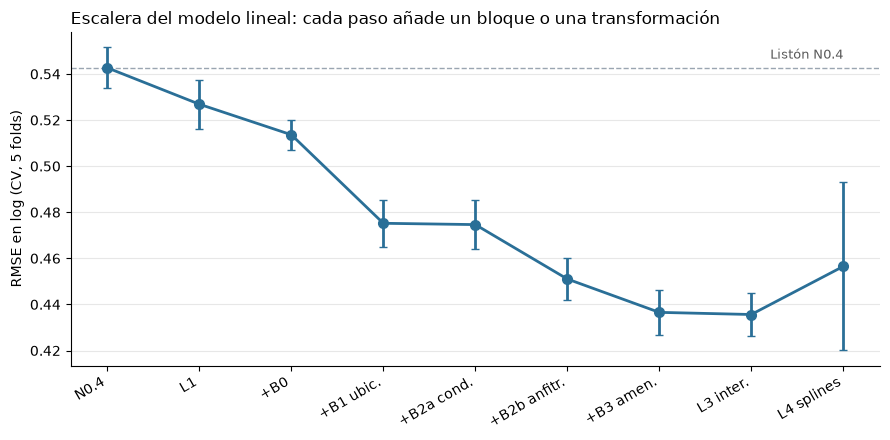

In [8]:
escalera = pd.concat([resumen_n0.loc[['N0.4_mediana_barrio_room_type']], resumen_l])
fig, ax = plt.subplots(figsize=(9, 4.5))
posiciones = np.arange(len(escalera))
ax.errorbar(posiciones, escalera['rmse_log_val_mean'], yerr=escalera['rmse_log_val_std'], fmt='o-', color=COLOR_BASE,
            lw=2, ms=7, capsize=3)
ax.axhline(resumen_n0.loc['N0.4_mediana_barrio_room_type', 'rmse_log_val_mean'], color=COLOR_SECUNDARIO, ls='--', lw=1)
ax.text(len(escalera) - 1, resumen_n0.loc['N0.4_mediana_barrio_room_type', 'rmse_log_val_mean'] + 0.004,
        'Listón N0.4', ha='right', color='0.35', fontsize=9)
etiquetas = ['N0.4', 'L1', '+B0', '+B1 ubic.', '+B2a cond.', '+B2b anfitr.', '+B3 amen.', 'L3 inter.', 'L4 splines']
ax.set_xticks(posiciones, etiquetas, rotation=30, ha='right')
ax.set_ylabel('RMSE en log (CV, 5 folds)')
ax.set_title('Escalera del modelo lineal: cada paso añade un bloque o una transformación', loc='left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Conclusiones:
**Un modelo aditivo ya explica el 63% de la varianza del log-precio; la ubicación y el perfil del anfitrión
son los dos grandes saltos después del producto.**

- **L1 (solo el producto básico) = 0,527**, casi igual que la referencia N0.3 (0,535): con tres variables, una recta hace lo mismo que la tabla de medianas.
- **La escalera aditiva (L2)**, en RMSE en log: producto completo **0,514** → + ubicación **0,475** (−0,038, el mayor salto) → + condiciones **0,475** (−0,0006: nada) → + anfitrión **0,451** (−0,024, el segundo) → + amenities comunes **0,436** (−0,015) → + lujo **0,435** (−0,001). R² final **0,626**. En dólares: MAE de $59 a $50 y mediana del error de $29 a $23.
- **Las interacciones (L3) apenas aportan (−0,001).** El modelo aditivo no necesita que el efecto de la capacidad cambie por tipo de habitación.
- **La OLS con *splines* (L4) es *inestable*:** 0,452 ± 0,030. 

### 5.1 L5: regularización (Ridge, Lasso, ElasticNet)

Con ~150 columnas tras codificar y ~24.000 anuncios por fold, la OLS no debería sobreajustar mucho, pero
la regularización puede ayudar con las amenities correlacionadas. Se prueba una rejilla de `alpha` para
Ridge (penaliza β², encoge sin anular), Lasso (penaliza |β|, anula coeficientes) y ElasticNet
(mezcla de ambos).  **Aviso:** el mejor `alpha` se elige mirando estos mismos 5 folds, así que su RMSE es algo
optimista.

,familia,alpha,experimento,rmse_log_val,rmse_log_val_sd
8,ElasticNet,0.0001,L5_ElasticNet_alpha_0.0001,0.4342,0.0087
5,Lasso,0.0001,L5_Lasso_alpha_0.0001,0.4342,0.0087
2,Ridge,10.0000,L5_Ridge_alpha_10,0.4344,0.0087


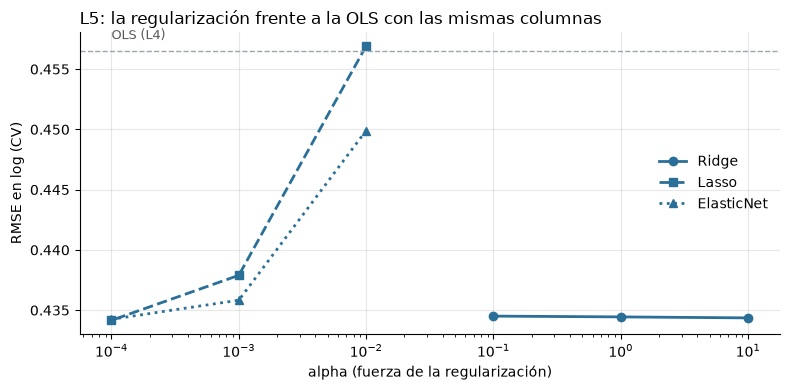

In [9]:
rejillas_l5 = {
    'Ridge': (Ridge, [0.1, 1, 10]),
    'Lasso': (lambda alpha: Lasso(alpha=alpha, max_iter=5000), [1e-2, 1e-3, 1e-4]),
    'ElasticNet': (lambda alpha: ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000), [1e-2, 1e-3, 1e-4]),
}

filas_l5 = []
for familia, (constructor, alphas) in rejillas_l5.items():
    for alpha in alphas:
        exp = lineal(f'L5_{familia}_alpha_{alpha:.2g}', COLS_B, constructor(alpha=alpha), splines=True,
                     interacciones=True)
                     
        res = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO, paralelo=5)
        filas_l5.append({'familia': familia, 'alpha': alpha, 'experimento': exp.nombre,
                         'rmse_log_val': res['rmse_log_val'].mean(), 'rmse_log_val_sd': res['rmse_log_val'].std()})
curvas_l5 = pd.DataFrame(filas_l5)
mejores_l5 = curvas_l5.loc[curvas_l5.groupby('familia')['rmse_log_val'].idxmin()]
display(mejores_l5.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for (familia, datos_f), estilo in zip(curvas_l5.groupby('familia', sort=False), ['o-', 's--', '^:']):
    ax.plot(datos_f['alpha'], datos_f['rmse_log_val'], estilo, color=COLOR_BASE, lw=2, ms=6, label=familia)
ax.axhline(resumen_l.loc['L4_splines', 'rmse_log_val_mean'], color=COLOR_SECUNDARIO, ls='--', lw=1)
ax.text(curvas_l5['alpha'].min(), resumen_l.loc['L4_splines', 'rmse_log_val_mean'] + 0.001, 'OLS (L4)', color='0.35',
        fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('alpha (fuerza de la regularización)')
ax.set_ylabel('RMSE en log (CV)')
ax.set_title('L5: la regularización frente a la OLS con las mismas columnas', loc='left')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Conclusiones:
**La regularización no mejora la precisión**

- **La curva de Ridge es plana,** Lasso y ElasticNet alcanzan su mejor valor en el `alpha` más pequeño probado.
- **Las tres familias empatan** (diferencias de 0,0001). Con n ≫ p no hay varianza que recortar.
- **Qué aporta, entonces:** estabilidad numérica frente a la OLS de L4 (el diseño con rango incompleto deja de explotar) y un camino de selección complementario (celda siguiente).

In [10]:
# Cuantos coeficientes anula el mejor Lasso, ajustado sobre el primer fold
mejor_lasso = mejores_l5.set_index('familia').loc['Lasso']
lasso = lineal('tmp', COLS_B, Lasso(alpha=mejor_lasso['alpha'], max_iter=5000), splines=True, interacciones=True).modelo
f0 = FOLDS_MODELOS[0]
lasso.fit(train[COLS_B].iloc[f0.train], train[TARGET].iloc[f0.train])
nombres_lasso = lasso[0][-1].get_feature_names_out()
coef_lasso = pd.Series(lasso[-1].coef_, index=nombres_lasso)
print(f"Lasso (alpha={mejor_lasso['alpha']:.2g}): {(coef_lasso == 0).sum()} de {len(coef_lasso)} coeficientes a cero")
anulados = coef_lasso[coef_lasso == 0].index.str.replace(r'^\w+__', '', regex=True)
print('\n'.join(f'  - {nombre}' for nombre in anulados))

Lasso (alpha=0.0001): 37 de 163 coeficientes a cero
  - property_type_grp_Entire guest suite
  - property_type_grp_Otros
  - district_Brooklyn
  - district_Staten Island
  - host_ambito_misma_ciudad
  - host_response_time_sin_dato
  - room_type_x_district_Entire place | Queens
  - room_type_x_district_Hotel room | Brooklyn
  - room_type_x_district_Hotel room | Manhattan
  - room_type_x_district_Hotel room | Queens
  - room_type_x_district_Private room | Bronx
  - room_type_x_district_Private room | Staten Island
  - room_type_x_district_Shared room | Bronx
  - room_type_x_district_Shared room | Manhattan
  - room_type_x_district_Shared room | Queens
  - room_type_x_district_Shared room | Staten Island
  - missingindicator_host_response_rate
  - accommodates_sp_4
  - accommodates_sp_9
  - latitude_sp_0
  - latitude_sp_1
  - latitude_sp_2
  - latitude_sp_8
  - latitude_sp_9
  - longitude_sp_0
  - longitude_sp_1
  - longitude_sp_2
  - longitude_sp_3
  - longitude_sp_5
  - longitude_sp_8
 

#### Conclusiones:
**Lo que Lasso anula es sobre todo redundancia del diseño, no variables candidatas.**

- **37 de 163 coeficientes a cero.** Nueve son celdas de `room_type` × `district` con pocos anuncios
  (hoteles, habitaciones compartidas y privadas en distritos pequeños), son columnas que el propio diseño hace redundantes. El resto son de splines sobre todo de lon/lat.
- **Tres distritos (Manhattan, Queens, Staten Island) tienen el efecto principal a cero.** No significa que la zona no importe: `room_type` × `district` y la distancia al centro ya recogen ese efecto, y Lasso conserva solo una de las columnas que repiten la misma información.
- **De las variables candidatas desaparecen pocas categorías:** un tipo de propiedad (`Entire guest suite`) y tres del perfil del anfitrión (`host_ambito = misma_ciudad`, `host_response_time = sin_dato` y el indicador de nulo de `host_response_rate`).

### 5.2 Inferencia: coeficientes hedónicos con errores agrupados por anfitrión

Para leer los coeficientes como % del precio se ajusta una OLS sobre todo el train (no se predice nada, así que no hace falta CV). Especificación **interpretable**: se quita lo que no tiene lectura lineal (el barrio codificado por el target y lat/lon en bruto) y se deja el distrito y la distancia al centro. Se quitan además dos redundancias exactas que harían los coeficientes arbitrarios: `property_type_grp`, que **anida** `room_type` (cada tipo de propiedad pertenece a un solo tipo de habitación), y el indicador de nulo de `host_response_rate`, que **coincide** con
`host_response_time = 'sin_dato'`. Las numéricas van **sin escalar**, para que el coeficiente sea "por huésped" o "por km".

**Errores estándar agrupados por `host_id`** (`cov_type='cluster'`): los anuncios de un mismo anfitrión no son independientes, y sin agrupar los intervalos saldrían demasiado estrechos. Es la misma lógica que el split. **Son asociaciones condicionadas, no efectos causales:** "a igualdad del resto de variables, los anuncios con X cuestan un Y% más".

In [11]:
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

datos_ols = train.copy()
datos_ols['log_estancia'] = np.log1p(datos_ols['minimum_nights'].clip(upper=RECORTE_ESTANCIA))
datos_ols['log_anuncios_ny'] = np.log1p(datos_ols['n_anuncios_ny'])
# El nulo de host_response_rate coincide exactamente con host_response_time = 'sin_dato': no lleva indicador propio
assert (datos_ols['host_response_rate'].isna() == (datos_ols['host_response_time'] == 'sin_dato')).all()
for col in ['host_response_rate', 'host_acceptance_rate', 'reputacion_cartera', 'antiguedad_host_anios']:
    datos_ols[f'{col}_nulo'] = datos_ols[col].isna().astype(int)
    datos_ols[col] = datos_ols[col].fillna(datos_ols[col].median())
amenities = columnas_de(bloques, ['B3_amenities_comunes'])
binarias = ['es_estudio', 'estancia_min_30', 'instant_bookable', 'host_is_superhost', 'host_identity_verified'] + amenities
datos_ols[binarias] = datos_ols[binarias].astype(int)

formula = ('log_price ~ C(room_type, Treatment("Entire place")) + accommodates + bedrooms + es_estudio'
           ' + C(district, Treatment("Manhattan")) + dist_centro_km'
           ' + log_estancia + estancia_min_30 + instant_bookable'
           ' + antiguedad_host_anios + antiguedad_host_anios_nulo + log_anuncios_ny + host_is_superhost'
           ' + host_identity_verified + C(host_ambito) + C(host_response_time, Treatment("sin_dato"))'
           ' + host_response_rate + host_acceptance_rate + host_acceptance_rate_nulo'
           ' + reputacion_cartera + reputacion_cartera_nulo + ' + ' + '.join(amenities))
ols = smf.ols(formula, data=datos_ols).fit(cov_type='cluster', cov_kwds={'groups': datos_ols[COL_GRUPO]})
print(f"OLS hedónica: R² = {ols.rsquared:.3f} (en train, sin CV) | {int(ols.df_model)} coeficientes | "
      f"{datos_ols[COL_GRUPO].nunique():,} grupos de anfitrión")

ic = ols.conf_int()
coeficientes = pd.DataFrame({
    'efecto_pct': (np.exp(ols.params) - 1) * 100,
    'ic95_inf_pct': (np.exp(ic[0]) - 1) * 100,
    'ic95_sup_pct': (np.exp(ic[1]) - 1) * 100,
    'p_valor': ols.pvalues,
}).drop(index='Intercept')
coeficientes.index = (coeficientes.index.str.replace(r'C\((\w+)(, Treatment\("[^"]+"\))?\)\[T\.', r'\1 = ', regex=True)
                      .str.replace(']', '', regex=False))
principales = [c for c in coeficientes.index if not c.startswith('am_')]
coef_principales = coeficientes.loc[principales]
display(coef_principales.round(3).sort_values('efecto_pct'))

OLS hedónica: R² = 0.612 (en train, sin CV) | 87 coeficientes | 21,368 grupos de anfitrión


,efecto_pct,ic95_inf_pct,ic95_sup_pct,p_valor
room_type = Shared room,-50.427,-54.335,-46.185,0.000
room_type = Private room,-40.141,-41.686,-38.554,0.000
district = Brooklyn,-23.816,-25.171,-22.436,0.000
district = Staten Island,-19.806,-25.071,-14.171,0.000
district = Queens,-16.417,-18.690,-14.081,0.000
host_response_time = within a few hours,-14.054,-17.707,-10.240,0.000
host_response_time = within an hour,-13.655,-16.268,-10.960,0.000
es_estudio,-12.602,-14.917,-10.224,0.000
antiguedad_host_anios_nulo,-12.317,-27.158,5.548,0.165
host_response_time = within a day,-10.311,-13.872,-6.602,0.000


In [12]:
# Mismo contraste sin agrupar, para ver cuanto se estrechan los intervalos si se ignora al anfitrion
ols_sin_agrupar = smf.ols(formula, data=datos_ols).fit()
ratio_ee = (ols.bse / ols_sin_agrupar.bse).drop('Intercept')
print(f"Error estándar agrupado / sin agrupar: mediana {ratio_ee.median():.2f}, "
      f"rango [{ratio_ee.min():.2f},{ratio_ee.max():.2f}]")
print(f"Coeficientes significativos (p < 0,05): {(ols_sin_agrupar.pvalues.drop('Intercept') < 0.05).sum()} sin agrupar, "
      f"{(ols.pvalues.drop('Intercept') < 0.05).sum()} agrupando por anfitrión")

Error estándar agrupado / sin agrupar: mediana 1.52, rango [0.77,3.60]
Coeficientes significativos (p < 0,05): 55 sin agrupar, 47 agrupando por anfitrión


#### Conclusiones:
**Los coeficientes hedónicos son asociaciones condicionadas, no efectos causales. Es decir, indican "a igualdad del resto de variables, los anuncios con X cuestan un Y% más". El precio lo fijan sobre todo el producto y la zona, y agrupar por anfitrión evita declarar significativos siete efectos que no lo son.**

- **Producto y ubicación mandan.** Una habitación privada cuesta un **40% menos** que un piso entero comparable y una compartida un **50% menos**. Cada dormitorio suma un **16%** y cada huésped, un **9%**. A la misma distancia del centro, Brooklyn es un **24% más barato** que Manhattan.
- **`instant_bookable` deja de ser significativa** (p = 0,43), porque su efecto marginal lo recoge el perfil del anfitrión. Y los anfitriones que responden en menos de un día cobran un **10%-15% menos** que los que no tienen dato de respuesta.
- **Agrupar importa:** los errores estándar agrupados por anfitrión son **1,5 veces mayores** (mediana, es mas realista) y los coeficientes significativvos bajan de **57 a 50**. Con el error estándar sin agrupar por anfitrión se habrían declarado siete efectos de más.

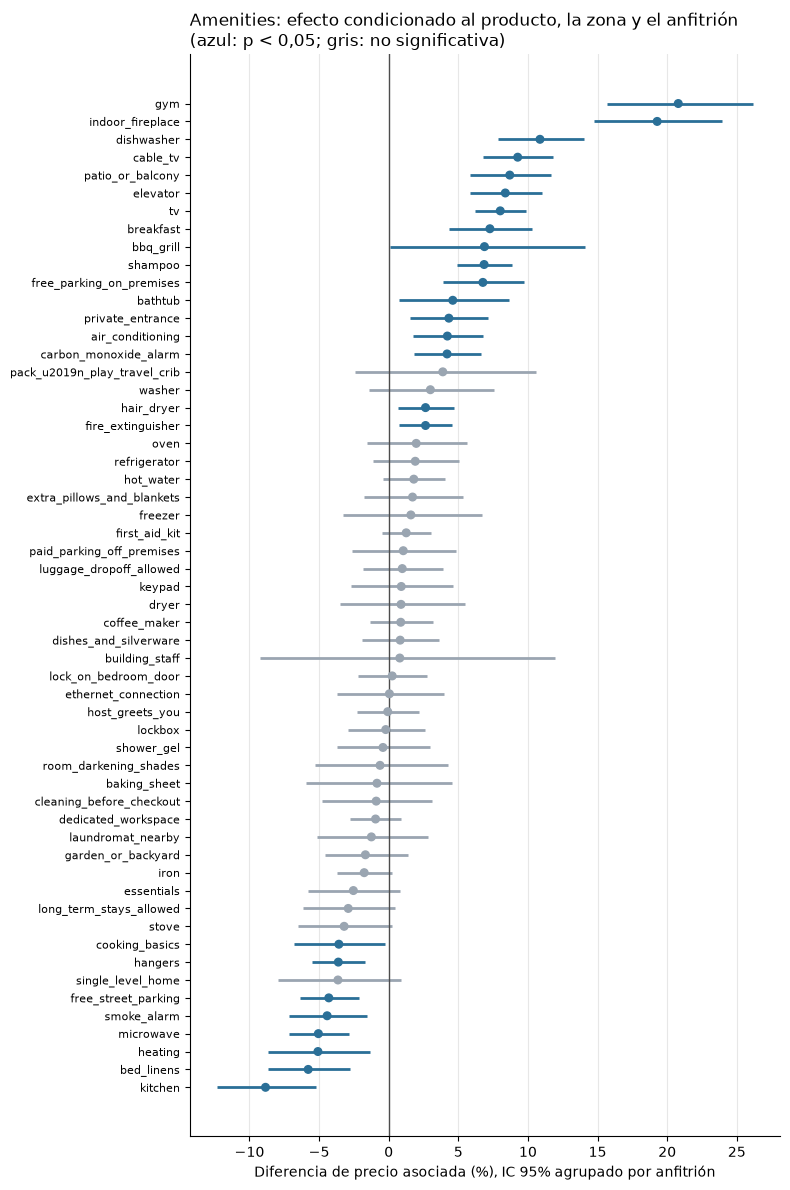

In [13]:
amen = coeficientes.loc[[c for c in coeficientes.index if c.startswith('am_')]].sort_values('efecto_pct')
fig, ax = plt.subplots(figsize=(8, 12))
significativa = (amen['p_valor'] < 0.05)
colores = np.where(significativa, COLOR_BASE, COLOR_SECUNDARIO)
ax.hlines(np.arange(len(amen)), amen['ic95_inf_pct'], amen['ic95_sup_pct'], color=colores, lw=2)
ax.scatter(amen['efecto_pct'], np.arange(len(amen)), color=colores, s=30, zorder=3)
ax.axvline(0, color='0.3', lw=1)
ax.set_yticks(np.arange(len(amen)), amen.index.str.replace('am_', ''), fontsize=8)
ax.set_xlabel('Diferencia de precio asociada (%), IC 95% agrupado por anfitrión')
ax.set_title('Amenities: efecto condicionado al producto, la zona y el anfitrión\n(azul: p < 0,05; gris: no significativa)',
             loc='left')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Conclusiones:
**Las amenities de ocio y de edificio de gama alta se asocian a precios más altos; las de cocina y estancia
larga, a precios más bajos.**

- **Primas mayores (+17% a +25%):** equipo de sonido, piscina, chimenea y gimnasio, junto con la jacuzzi privada.
  Son marcadores de edificios o viviendas de gama alta, no de la amenity en sí.
- **Primas intermedias (+8% a +11%):** lavavajillas, TV por cable, balcón o terraza, ascensor y TV.
- **Asociadas a precios más bajos (−4% a −6%):** utensilios de cocina, microondas, fogones, ropa de cama y
  perchas. Encajan con la habitación de estancia larga equipada para cocinar, más barata por noche.
- **Casi la mitad de las amenities comunes no es significativa** (en gris).


### 5.3 Diagnósticos de la OLS

- **Residuos frente a ajustados y QQ-plot:** forma de los errores y colas pesadas tipicas en precios.
- **Breusch-Pagan:** heterocedasticidad (casi segura con la cantidad de datos que tenemos). Si la hay, los errores agrupados (robustos) ya la cubren.
- **VIF** de las numéricas: colinealidad entre `accommodates` y `bedrooms`, y entre `dist_centro_km` y el
  distrito. Un VIF alto no sesga las predicciones, pero hace inestables los coeficientes individuales.
- **Residuos en el mapa:** si hay manchas, el lineal no captura la ubicación.

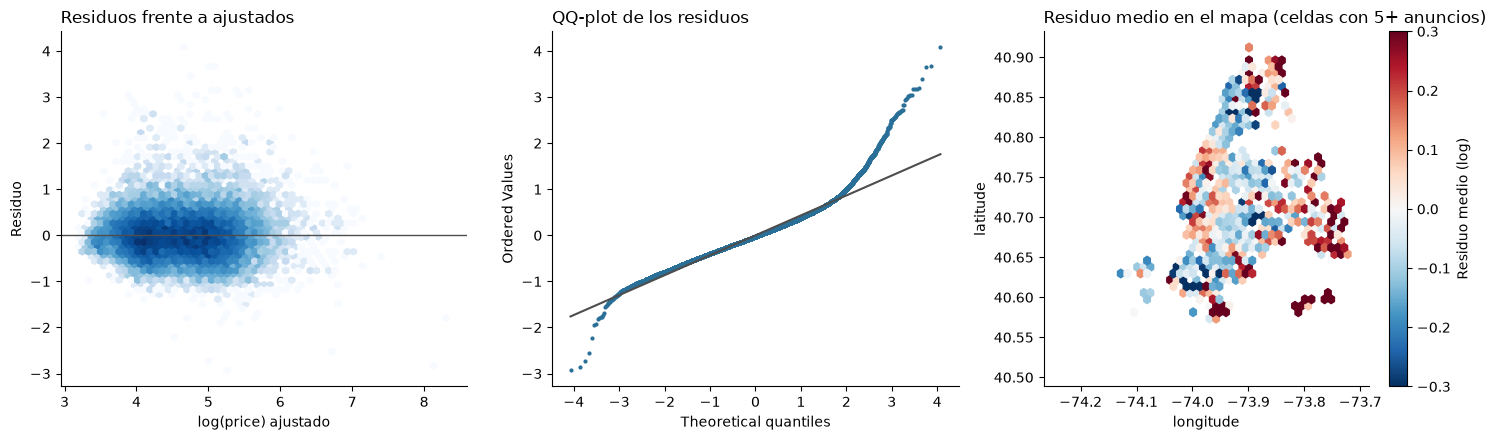

Breusch-Pagan: LM = 1121, p = 2.7e-179
Asimetría de los residuos 0.95, curtosis 4.42


,accommodates,bedrooms,dist_centro_km,log_estancia,log_anuncios_ny,antiguedad_host_anios,host_response_rate,host_acceptance_rate,reputacion_cartera
VIF,2.18,2.16,1.05,1.06,1.11,1.15,1.07,1.06,1.07


In [14]:
residuos = ols.resid
ajustados = ols.fittedvalues
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))
ejes[0].hexbin(ajustados, residuos, gridsize=60, cmap='Blues', mincnt=1, bins='log')
ejes[0].axhline(0, color='0.3', lw=1)
ejes[0].set_xlabel('log(price) ajustado')
ejes[0].set_ylabel('Residuo')
ejes[0].set_title('Residuos frente a ajustados', loc='left')

from scipy import stats as st
st.probplot(residuos, dist='norm', plot=ejes[1])
ejes[1].get_lines()[0].set(color=COLOR_BASE, markersize=2)
ejes[1].get_lines()[1].set(color='0.3')
ejes[1].set_title('')
ejes[1].set_title('QQ-plot de los residuos', loc='left')

mapa = ejes[2].hexbin(train['longitude'], train['latitude'], C=residuos, reduce_C_function=np.mean, gridsize=45,
                      cmap='RdBu_r', vmin=-0.3, vmax=0.3, mincnt=5)
fig.colorbar(mapa, ax=ejes[2], label='Residuo medio (log)')
ejes[2].set_title('Residuo medio en el mapa (celdas con 5+ anuncios)', loc='left')
ejes[2].set_xlabel('longitude')
ejes[2].set_ylabel('latitude')
for eje in ejes:
    eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

bp = het_breuschpagan(residuos, ols.model.exog)
print(f"Breusch-Pagan: LM = {bp[0]:.0f}, p = {bp[1]:.1e}")
print(f"Asimetría de los residuos {st.skew(residuos):.2f}, curtosis {st.kurtosis(residuos):.2f}")

numericas_vif = ['accommodates', 'bedrooms', 'dist_centro_km', 'log_estancia', 'log_anuncios_ny',
                 'antiguedad_host_anios', 'host_response_rate', 'host_acceptance_rate', 'reputacion_cartera']
matriz_vif = datos_ols[numericas_vif].assign(constante=1.0).to_numpy()
vif = pd.Series([variance_inflation_factor(matriz_vif, i) for i in range(len(numericas_vif))], index=numericas_vif)
display(vif.round(2).to_frame('VIF').T)

#### Conclusiones:
**Los supuestos de la OLS no se cumplen del todo, pero lo que falla está cubierto o apunta a lo que el modelo
no captura: la ubicación fina.**

- **Heterocedasticidad clara** (Breusch-Pagan, p ≈ 10⁻¹⁶⁰). No invalida los coeficientes, y los errores agrupados
  por anfitrión son robustos a ella.
- **Cola derecha pesada** (asimetría 0,95, curtosis 4,4 y el QQ-plot se separa por encima de +1,5): hay anuncios
  mucho más caros de lo que predice el modelo. Es el lujo que las variables no ven.
- **Sin problemas de colinealidad entre las numéricas:** VIF ≤ 2,2.
- **El mapa de residuos tiene manchas:** los residuos positivos se concentran en el este de Queens, las
  Rockaways y partes del norte de Manhattan, y los negativos en el sur de Brooklyn y Staten Island. **El lineal
  no captura la estructura local de la ubicación** con distrito + distancia. Es el hueco que tienen que llenar
  las coordenadas en un modelo no lineal (kNN, árboles).

## 7. SELECCIÓN DE VARIABLES

**Pregunta:** ¿qué variables aportan de verdad, medido igual para todas y con una regla fijada antes de
mirar?

 Para cada prueba, sobre las 15 estimaciones pareadas (5 folds × 3 repeticiones), `Δᵢ = RMSE_sin_var − RMSE_con_var`. Una variable o bloque **entra** si:

1. **Consistencia:** `Δᵢ > 0` en **al menos 12 de las 15** estimaciones, y
2. **Tamaño:** el **Δ medio supera su desviación típica** entre folds.

Es una **regla heurística**: los 15 Δ no son independientes (los folds comparten datos de entrenamiento),
así que no es un contraste con un nivel de significación conocido. Como dato informativo se muestra el p del
t-test pareado corregido de Nadeau y Bengio (2003), que tiene en cuenta esa dependencia.

**Modelo de referencia: Ridge con L4** (`alpha = 1`, el valor por defecto; *splines* e interacciones). La OLS sin penalizar se
descarta como referencia por su inestabilidad fuera del rango de los datos. No está ajustado: la selección no puede depender de
hiperparámetros elegidos con esas mismas variables (sería circular).

**La selección solo decide las variables de la familia lineal y de kNN (sección 7.3).** Los árboles, los ensembles, la cuantílica y el SVR usan las 79: eligen por sí mismos en qué variables cortan, y con los hiperparámetros ajustados quitarles variables les perjudica (sección 9.4). Por eso la ablación **no se repite con HGB** (bitácora, 10-02): su columna no decidía nada y costaba 480 ajustes. Las filas `F4_hgb_*` del 09-30 siguen en el registro como histórico.

**Cómo se leen las pruebas con varias alternativas (fijado antes de ejecutar):**

| Prueba | Comparaciones | Qué se queda |
|---|---|---|
| A3 ubicación | Cadena anidada: lat/lon → + `dist_centro_km` → + `district` → + barrio; y "completa" frente a "solo `district` + barrio" | Se sube un escalón mientras el escalón entra según D4. Las coordenadas se quedan si "completa" gana a "sin coordenadas" |
| A4 `minimum_nights` | En bruto frente a fuera; `estancia_min_30` frente a fuera; las dos frente a cada una | Las dos solo si ganan a las dos formas sueltas; si no, la forma suelta que entre con mayor Δ; si ninguna entra, fuera |
| A7 cartera | `n_anuncios_ny` frente a ninguna; `host_total_listings_count` frente a ninguna; las dos frente a cada una | Igual que A4 |
| Resto (A1, A2, A6, A8-A12) | Modelo completo frente al completo sin la variable o bloque | Entra si pasa D4 |

Las amenities entran o salen como bloque (A12): no se criban una a una (¿Agrupar amenities?).

**Coste:** 25 configuraciones × 15 folds = 375 ajustes. Los
resultados se guardan en `outputs/experimentos.csv` y se reutilizan al volver a ejecutar el notebook
(`evaluar_registrado`), salvo que cambien el modelo, las variables o los folds.

### 7.0 ¿Hay candidatas que midan lo mismo?

Antes de quitar bloques conviene saber qué pares de variables numéricas están tan relacionados que una puede
suplir a la otra. Es lo que explica que una ablación a veces no note la ausencia de una variable: otra la
cubre. Se mira solo entre explicativas, sin `price`.

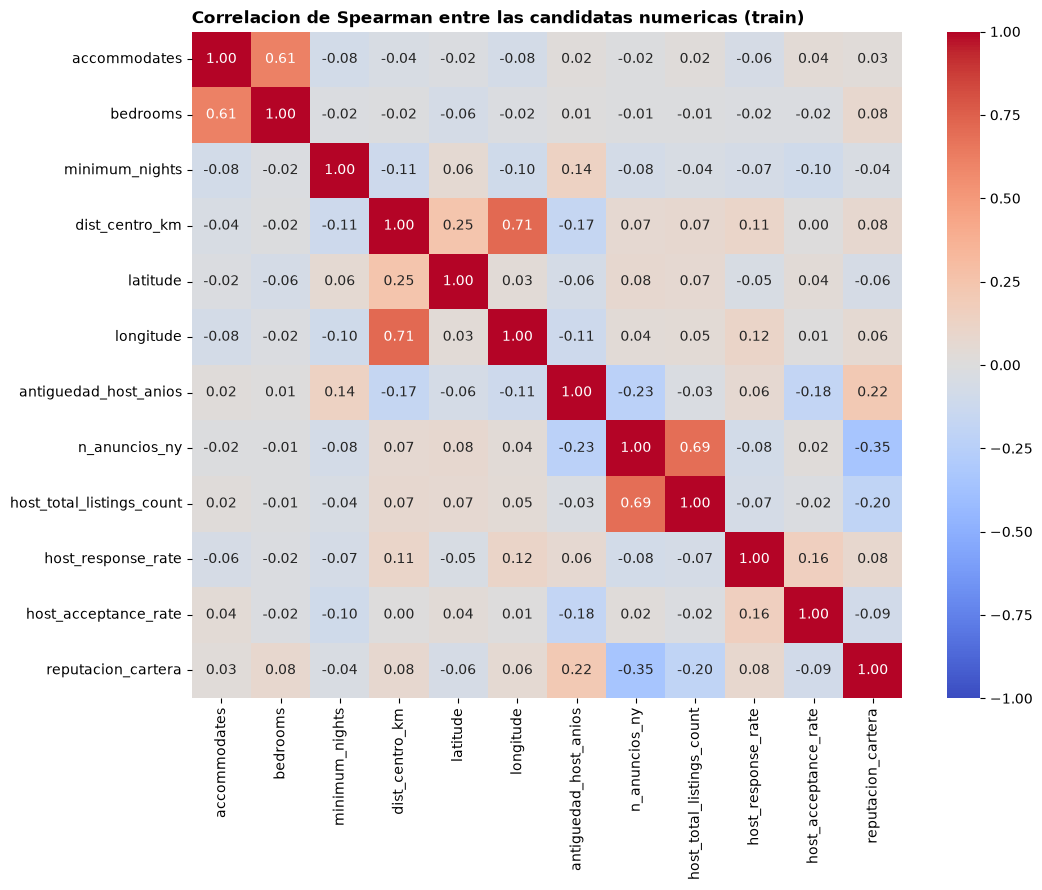

,var_1,var_2,rho,n
0,dist_centro_km,longitude,0.712,29538
1,n_anuncios_ny,host_total_listings_count,0.691,29523
2,accommodates,bedrooms,0.611,29538
3,n_anuncios_ny,reputacion_cartera,-0.350,9861
4,dist_centro_km,latitude,0.246,29538
5,antiguedad_host_anios,n_anuncios_ny,-0.232,29523
6,antiguedad_host_anios,reputacion_cartera,0.217,9858
7,host_total_listings_count,reputacion_cartera,-0.202,9858


In [15]:
cols_num = ['accommodates', 'bedrooms', 'minimum_nights', 'dist_centro_km', 'latitude', 'longitude',
            'antiguedad_host_anios', 'n_anuncios_ny', 'host_total_listings_count', 'host_response_rate',
            'host_acceptance_rate', 'reputacion_cartera']
corr_spearman = train[cols_num].corr(method='spearman')

fig, eje = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=eje)
eje.set_title('Correlacion de Spearman entre las candidatas numericas (train)', loc='left', fontsize=12.5,
              fontweight='bold')
plt.tight_layout()
plt.show()

# n cuenta los pares sin nulos: reputacion_cartera solo la tiene un tercio de los anuncios
filas = []
for a, b in combinations(cols_num, 2):
    sub = train[[a, b]].dropna()
    filas.append({'var_1': a, 'var_2': b, 'rho': round(spearmanr(sub[a], sub[b]).statistic, 3), 'n': len(sub)})
display(pd.DataFrame(filas).sort_values('rho', key=abs, ascending=False).head(8).reset_index(drop=True))

#### Conclusiones:

No hay multicolinealidad grave, pero hay tres pares bastante relacionados que condicionan cómo se lee la
ablación que viene a continuación.

- `dist_centro_km` y `longitude` (ρ = 0,71): es por construcción, el centro queda al suroeste de la mayoría de
  anuncios. Complica interpretar los coeficientes del lineal; **la prueba A3 decide qué forma de la ubicación
  entra**.
- `n_anuncios_ny` y `host_total_listings_count` (ρ = 0,69): miden lo mismo y no se complementan. **La A7 elige
  una de las dos.**
- `accommodates` y `bedrooms` (ρ = 0,61): se quedan las dos, porque a igual capacidad los dormitorios siguen
  moviendo el precio (`2-ANALISIS` sección 4.2).
- `reputacion_cartera` y `n_anuncios_ny` (ρ = −0,35): los anfitriones con más anuncios tienen peor reputación
  media. Hay que tenerlo presente al interpretar cualquiera de las dos.

In [16]:
REFERENCIAS_F4 = {'Ridge': referencia_ridge}


B = {nombre: bloques[nombre] for nombre in ESCALERA_BLOQUES}

configuraciones = {'completo': COLS_B}
for nombre_bloque, cols in B.items():
    configuraciones[f'sin_{nombre_bloque}'] = sin(COLS_B, cols)
for nombre, quitar in {
    'A1_sin_es_estudio': ['es_estudio'],
    'A2_sin_property_type_grp': ['property_type_grp'],
    'A3_solo_coordenadas': ['dist_centro_km', 'district', 'neighbourhood'],
    'A3_coordenadas_distancia': ['district', 'neighbourhood'],
    'A3_coordenadas_distancia_distrito': ['neighbourhood'],
    'A3_sin_coordenadas': COORDENADAS + ['dist_centro_km'],
    'A4_estancia_fuera': ['minimum_nights', 'estancia_min_30'],
    'A4_estancia_bruto': ['estancia_min_30'],
    'A4_estancia_min_30': ['minimum_nights'],
    'A6_sin_instant_bookable': ['instant_bookable'],    
    'A7_cartera_ninguna': ['n_anuncios_ny', 'host_total_listings_count'],
    'A7_cartera_n_anuncios_ny': ['host_total_listings_count'],
    'A7_cartera_total_listings': ['n_anuncios_ny'],
    'A8_sin_reputacion_cartera': ['reputacion_cartera'],
    'A9_sin_tasas': TASAS,
    'A10_sin_host_identity_verified': ['host_identity_verified'],
    'A10_sin_host_is_superhost': ['host_is_superhost'],
    'A10_sin_host_ambito': ['host_ambito'],
    'A10_sin_antiguedad_host_anios': ['antiguedad_host_anios'],

}.items():
    configuraciones[nombre] = sin(COLS_B, quitar)
print(f"{len(configuraciones)} configuraciones × {len(FOLDS_SELECCION)} folds")

25 configuraciones × 15 folds


In [17]:
resultados_f4 = {}
for modelo, construir in REFERENCIAS_F4.items():
    for nombre, columnas in configuraciones.items():
        resultados_f4[(modelo, nombre)] = evaluar_registrado(construir(nombre, columnas), train, FOLDS_SELECCION,
                                                             RUTA_REGISTRO)

resumen_f4 = pd.DataFrame([
    {'modelo': modelo, 'configuracion': nombre, 'n_variables': len(configuraciones[nombre]),
     'rmse_log_val': res['rmse_log_val'].mean(), 'rmse_log_val_sd': res['rmse_log_val'].std(), 'mae_usd_val': res['mae_usd_val'].mean()}
    for (modelo, nombre), res in resultados_f4.items()
])
display(resumen_f4.pivot(index='configuracion', columns='modelo', values='rmse_log_val')
        .loc[list(configuraciones)].round(4))

modelo,Ridge
configuracion,
completo,0.4350
sin_B0_producto,0.5461
sin_B1_ubicacion,0.4666
sin_B2a_condiciones,0.4360
sin_B2b_anfitrion,0.4521
sin_B3_amenities_comunes,0.4489
A1_sin_es_estudio,0.4372
A2_sin_property_type_grp,0.4380
A3_solo_coordenadas,0.4397


### 7.1 Quitando un bloque cada vez

Sobre el modelo completo: cuánto se pierde al quitar cada bloque, **condicionado a todos los demás**. Es
la prueba más exigente, porque los demás bloques pueden compensar la ausencia (por ejemplo, el barrio
puede suplir parte de las amenities de zonas caras).

In [18]:
def decision(modelo, con, sin_):
    """Compara por pares (mismos folds) la configuracion `con` frente a `sin_` de un modelo y aplica la regla D4."""
    return comparar_pareado(resultados_f4[(modelo, con)], resultados_f4[(modelo, sin_)])


tabla_bloques = pd.DataFrame([
    {'modelo': modelo, 'bloque': nombre_bloque, **decision(modelo, 'completo', f'sin_{nombre_bloque}')}
    for modelo in REFERENCIAS_F4 for nombre_bloque in B
])
display(tabla_bloques.round(4))

,modelo,bloque,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
0,Ridge,B0_producto,0.1112,0.0084,15/15,0.0000,True
1,Ridge,B1_ubicacion,0.0317,0.0041,15/15,0.0000,True
2,Ridge,B2a_condiciones,0.0010,0.0008,14/15,0.0211,True
3,Ridge,B2b_anfitrion,0.0172,0.0065,15/15,0.0002,True
4,Ridge,B3_amenities_comunes,0.0139,0.0024,15/15,0.0000,True


### 7.2 Pruebas A1-A12

Lista cerrada del plan de modelado (sección 5.2). Cada fila compara el modelo con la variable (o la forma) frente al modelo
sin ella, con los mismos 15 folds.

In [19]:
pruebas = [
    ('A1', 'es_estudio', 'completo', 'A1_sin_es_estudio'),
    ('A2', 'property_type_grp', 'completo', 'A2_sin_property_type_grp'),
    ('A3', '+ dist_centro_km sobre lat/lon', 'A3_coordenadas_distancia', 'A3_solo_coordenadas'),
    ('A3', '+ district', 'A3_coordenadas_distancia_distrito', 'A3_coordenadas_distancia'),
    ('A3', '+ barrio', 'completo', 'A3_coordenadas_distancia_distrito'),
    ('A3', 'coordenadas sobre district + barrio', 'completo', 'A3_sin_coordenadas'),
    ('A4', 'minimum_nights en bruto (frente a fuera)', 'A4_estancia_bruto', 'A4_estancia_fuera'),
    ('A4', 'estancia_min_30 (frente a fuera)', 'A4_estancia_min_30', 'A4_estancia_fuera'),
    ('A4', 'las dos frente a solo en bruto', 'completo', 'A4_estancia_bruto'),
    ('A4', 'las dos frente a solo estancia_min_30', 'completo', 'A4_estancia_min_30'),
    ('A6', 'instant_bookable', 'completo', 'A6_sin_instant_bookable'),
    ('A7', 'n_anuncios_ny (frente a ninguna)', 'A7_cartera_n_anuncios_ny', 'A7_cartera_ninguna'),
    ('A7', 'host_total_listings_count (frente a ninguna)', 'A7_cartera_total_listings', 'A7_cartera_ninguna'),
    ('A7', 'las dos frente a solo n_anuncios_ny', 'completo', 'A7_cartera_n_anuncios_ny'),
    ('A7', 'las dos frente a solo total_listings', 'completo', 'A7_cartera_total_listings'),
    ('A8', 'reputacion_cartera', 'completo', 'A8_sin_reputacion_cartera'),
    ('A9', 'tasas de respuesta y aceptación', 'completo', 'A9_sin_tasas'),
    ('A10', 'host_identity_verified', 'completo', 'A10_sin_host_identity_verified'),
    ('A10', 'host_is_superhost', 'completo', 'A10_sin_host_is_superhost'),
    ('A10', 'host_ambito', 'completo', 'A10_sin_host_ambito'),
    ('A10', 'antiguedad_host_anios', 'completo', 'A10_sin_antiguedad_host_anios'),
    ('A12', 'bloque B3 (amenities comunes)', 'completo', 'sin_B3_amenities_comunes'),
]
tabla_pruebas = pd.DataFrame([
    {'prueba': id_, 'que_se_prueba': texto, 'modelo': modelo, **decision(modelo, con, sin_)}
    for id_, texto, con, sin_ in pruebas for modelo in REFERENCIAS_F4
])
vista = tabla_pruebas.pivot_table(index=['prueba', 'que_se_prueba'], columns='modelo',
                                  values=['delta_medio', 'delta_sd', 'folds_mejora', 'p_nadeau_bengio', 'entra'],
                                  aggfunc='first', sort=False)
vista = vista.reindex(columns=['delta_medio', 'delta_sd', 'folds_mejora', 'p_nadeau_bengio', 'entra'], level=0)
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(vista)

delta_medio delta_sd  \
modelo                                                    Ridge    Ridge   
prueba que_se_prueba                                                       
A1     es_estudio                                        0.0022   0.0010   
A2     property_type_grp                                 0.0031   0.0013   
A3     + dist_centro_km sobre lat/lon                    0.0011   0.0008   
       + district                                        0.0012   0.0005   
       + barrio                                          0.0024   0.0008   
       coordenadas sobre district + barrio               0.0028   0.0010   
A4     minimum_nights en bruto (frente a fuera)          0.0008   0.0007   
       estancia_min_30 (frente a fuera)                  0.0003   0.0004   
       las dos frente a solo en bruto                    0.0002   0.0003   
       las dos frente a solo estancia_min_30             0.0007   0.0005   
A6     instant_bookable                                  0.0000   0.0002   
A7     n_anuncios_ny (frente a ninguna)                  0.0018   0.0030   
       host_total_listings_count (frente a ninguna)     -0.0001   0.0005   
       las dos frente a solo n_anuncios_ny              -0.0006   0.0029   
       las dos frente a solo total_listings              0.0014   0.0053   
A8     reputacion_cartera                                0.0004   0.0007   
A9     tasas de respuesta y aceptación                   0.0047   0.0021   
A10    host_identity_verified                           -0.0000   0.0002   
       host_is_superhost                                 0.0002   0.0005   
       host_ambito                                       0.0004   0.0004   
       antiguedad_host_anios                             0.0001   0.0004   
A12    bloque B3 (amenities comunes)                     0.0139   0.0024   

                                                    folds_mejora  \
modelo                                                     Ridge   
prueba que_se_prueba                                               
A1     es_estudio                                          15/15   
A2     property_type_grp                                   15/15   
A3     + dist_centro_km sobre lat/lon                      13/15   
       + district                                          15/15   
       + barrio                                            15/15   
       coordenadas sobre district + barrio                 15/15   
A4     minimum_nights en bruto (frente a fuera)            13/15   
       estancia_min_30 (frente a fuera)                    12/15   
       las dos frente a solo en bruto                      14/15   
       las dos frente a solo estancia_min_30               14/15   
A6     instant_bookable                                    10/15   
A7     n_anuncios_ny (frente a ninguna)                    10/15   
       host_total_listings_count (frente a ninguna)         5/15   
       las dos frente a solo n_anuncios_ny                 11/15   
       las dos frente a solo total_listings                12/15   
A8     reputacion_cartera                                  10/15   
A9     tasas de respuesta y aceptación                     15/15   
A10    host_identity_verified                               7/15   
       host_is_superhost                                   10/15   
       host_ambito                                         13/15   
       antiguedad_host_anios                                9/15   
A12    bloque B3 (amenities comunes)                       15/15   

                                                    p_nadeau_bengio  entra  
modelo                                                        Ridge  Ridge  
prueba que_se_prueba                                                        
A1     es_estudio                                            0.0007   True  
A2     property_type_grp                                     0.0004   True  
A3     + dist_centro_km sobre lat/lon                        0.01

### 7.3 Conjunto seleccionado con Ridge

La selección se aplica **mecánicamente** a las tablas anteriores, con las reglas fijadas antes de ejecutar: se parte
del modelo completo y se quita todo lo que no entra en Ridge. El conjunto resultante (`VARS_RIDGE`) lo usan **la
familia lineal y kNN**, a los que una variable inútil sí perjudica: el lineal estima un coeficiente para cada una y
kNN la mete en la distancia.

**Los árboles, los ensembles, la cuantílica y el SVR usan las 79 (`COLS_B`)** (D1, bitácora 10-01). La selección con
HGB por defecto se ha retirado (la ablación ya no se calcula con HGB, bitácora 10-02): con los hiperparámetros ajustados, RF y HGB pierden al quitarles las variables que
descartaba (sección 9.4). El SVR también usa las 79 porque con ellas gana a las 71 de Ridge (sección 10.2).

In [20]:
VARS_RIDGE, FUERA_RIDGE = seleccionar_variables('Ridge', tabla_pruebas, COLS_B, B)
print(f"Ridge: {len(VARS_RIDGE)} variables | fuera ({len(FUERA_RIDGE)}): {', '.join(FUERA_RIDGE) if FUERA_RIDGE else 'ninguna'}")

# Escenario A (contraste, D1): las variables de cada familia sin el perfil del anfitrion
VARS_RIDGE_A = sin(VARS_RIDGE, B['B2b_anfitrion'])
COLS_B_A = sin(COLS_B, B['B2b_anfitrion'])

Ridge: 71 variables | fuera (8): antiguedad_host_anios, estancia_min_30, host_identity_verified, host_is_superhost, host_total_listings_count, instant_bookable, n_anuncios_ny, reputacion_cartera


In [21]:
# Comprobacion: el conjunto seleccionado no debe perder frente al completo al quitar todo a la vez
res_sel_ridge = evaluar_registrado(referencia_ridge('seleccionado', VARS_RIDGE), train, FOLDS_SELECCION, RUTA_REGISTRO)
comprobacion = {'rmse_completo': resultados_f4[('Ridge', 'completo')]['rmse_log_val'].mean(),
                'rmse_seleccionado': res_sel_ridge['rmse_log_val'].mean(), 'n_variables': len(VARS_RIDGE),
                **comparar_pareado(resultados_f4[('Ridge', 'completo')], res_sel_ridge)}
display(pd.Series(comprobacion, name='Ridge').to_frame().T.rename(columns={'entra': 'completo_gana'}))

,rmse_completo,rmse_seleccionado,n_variables,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,completo_gana
Ridge,0.434963,0.439396,71,0.004433,0.005434,12/15,0.084573,False


#### Conclusiones:
**La selección con Ridge deja 71 de las 79 variables y, quitando las 8 a la vez, el lineal pierde algo de precisión, pero la pérdida no supera la regla de decisión: el conjunto seleccionado se mantiene, como caso límite.**

- **Eliminadas:** 8 variables, 6 de ellas del perfil del anfitrión más `estancia_min_30` e `instant_bookable`. Del anfitrión se quedan las tasas de respuesta y aceptación, `host_response_time` y `host_ambito`.
- **Comprobación conjunta (observado):** el completo (0,4350) gana al seleccionado (0,4394) por **Δ = 0,0044** en **12 de 15** estimaciones. Cumple la consistencia (≥ 12/15) pero **no el tamaño**: el Δ medio no supera su desviación típica (0,0054).
- **Interpretación:** cada variable se decidió por separado, condicionada al resto. Al quitarlas todas a la vez se suman efectos pequeños que, uno a uno, no pasaban la regla: el perfil del anfitrión aporta como bloque, aunque sus variables sueltas sean en parte redundantes entre sí.


### 7.4 Ajuste del modelo lineal: 71 variables frente a 79

Búsqueda aleatoria sobre las **71 variables de Ridge**, con *splines* e interacciones (L4) y los mismos 5 folds. En lugar
de `RandomizedSearchCV` se muestrean las combinaciones con `ParameterSampler` y cada una se evalúa con
`evaluar_registrado` (función `buscar`): es la misma búsqueda, pero cada candidato queda en `outputs/experimentos.csv`
con sus métricas fold a fold, así que se puede comparar de forma pareada. `buscar` se reutiliza en RF, HGB y CatBoost.

| Modelo | Espacio | Qué controla |
|---|---|---|
| Ridge | `alpha` log [1e-2, 1e3], 10 candidatos | Fuerza de la penalización: más `alpha` = más sesgo y menos varianza |
| ElasticNet | `alpha` log [1e-4, 1e-2] × `l1_ratio` ∈ {0,5; 1}, 10 candidatos | Además, cuánto pesa L1 (anula coeficientes) frente a L2 (los encoge) |

El mejor candidato se compara de forma **pareada** con el mejor L5 que obtuvimos antes, que usa **las 79** con el mismo
preprocesado. **Regla (D1, fijada antes de ejecutar):** el lineal se queda con las 71 salvo que las 79 ganen según la regla: Δ > 0 en 4 de 5 folds y Δ medio mayor que su desviación típica. El ganador es `MEJOR_RIDGE`, que usan la tabla comparativa y el escenario A.

**Aviso:** el RMSE del mejor candidato es algo optimista, porque se elige mirando estos mismos folds.

In [22]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import ParameterSampler


def buscar(prefijo, construir, espacio, n_iter, paralelo=1, solo_leer=False):
    """Busqueda aleatoria (func_modelado.buscar_hiperparametros) con los datos y folds de este notebook."""
    return buscar_hiperparametros(prefijo, construir, espacio, n_iter, train, FOLDS_MODELOS, RUTA_REGISTRO, paralelo,
                                  solo_leer)


busqueda_lineal = pd.concat([
    buscar('T7_ridge', lambda nombre, p: lineal(nombre, VARS_RIDGE, Ridge(**p), splines=True, interacciones=True),
           {'alpha': np.logspace(-2, 3, 10)}, 10),
    buscar('T7_elasticnet', lambda nombre, p: lineal(nombre, VARS_RIDGE, ElasticNet(max_iter=5000, **p), splines=True,
                                                     interacciones=True),
           {'alpha': np.logspace(-4, -2, 5), 'l1_ratio': [0.5, 1.0]}, 10, paralelo=5),
]).sort_values('rmse_log_val')
display(busqueda_lineal.head(5).round(4))

# El mejor T7 (71 variables) frente al mejor L5 de sección 5.1 (79), con los mismos folds. Delta positivo = ganan las 79
L1_RATIO_L5 = {'Ridge': np.nan, 'Lasso': 1.0, 'ElasticNet': 0.5}
mejor_l5 = mejores_l5.sort_values('rmse_log_val').iloc[0]
mejor_t7 = busqueda_lineal.iloc[0]
res_l5 = filas_registro(mejor_l5['experimento'], RUTA_REGISTRO)
res_t7 = filas_registro(mejor_t7['experimento'], RUTA_REGISTRO)
comparacion_lineal = comparar_pareado(res_l5, res_t7)
display(pd.DataFrame({
    'experimento': [mejor_t7['experimento'], mejor_l5['experimento']],
    'n_variables': [len(VARS_RIDGE), len(COLS_B)],
    'rmse_log_val': [res_t7['rmse_log_val'].mean(), res_l5['rmse_log_val'].mean()],
    'rmse_log_val_sd': [res_t7['rmse_log_val'].std(), res_l5['rmse_log_val'].std()],
}, index=['T7 (71, ajustado)', 'L5 (79)']).round(4))
display(pd.Series(comparacion_lineal, name='79 frente a 71').to_frame().T.rename(columns={'entra': 'gana_all_vars'}))

if comparacion_lineal['entra']:
    MEJOR_RIDGE = pd.Series({'experimento': mejor_l5['experimento'], 'alpha': mejor_l5['alpha'],
                             'l1_ratio': L1_RATIO_L5[mejor_l5['familia']]})
    VARS_LINEAL = COLS_B
else:
    MEJOR_RIDGE = mejor_t7
    VARS_LINEAL = VARS_RIDGE
VARS_LINEAL_A = sin(VARS_LINEAL, B['B2b_anfitrion'])
print(f"Lineal elegido: {MEJOR_RIDGE['experimento']} con {len(VARS_LINEAL)} variables")


,alpha,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train,t_ajuste_s,l1_ratio
1,0.0001,T7_elasticnet_01,0.4390,0.0125,0.4294,20.1270,1.0
0,0.0001,T7_elasticnet_00,0.4391,0.0125,0.4293,24.5305,0.5
2,0.0003,T7_elasticnet_02,0.4391,0.0123,0.4297,13.6880,0.5
5,5.9948,T7_ridge_05,0.4392,0.0124,0.4294,0.2285,NaN
4,1.6681,T7_ridge_04,0.4392,0.0124,0.4292,1.2440,NaN


,experimento,n_variables,rmse_log_val,rmse_log_val_sd
"T7 (71, ajustado)",T7_elasticnet_01,71,0.4390,0.0125
L5 (79),L5_Lasso_alpha_0.0001,79,0.4342,0.0087


,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,gana_all_vars
79 frente a 71,0.004863,0.005312,4/5,0.122035,False


Lineal elegido: T7_elasticnet_01 con 71 variables


#### Conclusiones:
**Ajustar los hiperparámetros del lineal no cambia nada, y las 79 variables no ganan a las 71 según la regla fijada: el lineal se queda con las 71 de Ridge (`T7_elasticnet_01`, RMSE 0,4390) por simplicidad.**

- **El ajuste es plano (observado):** los cinco mejores candidatos están entre 0,4390 y 0,4392. El mejor es un ElasticNet con `l1_ratio = 1` (Lasso) y `alpha = 1e-4`, casi sin penalización. Un Ridge con `alpha ≈ 6` empata (0,4392) y ajusta en 0,2 s frente a 20 s. Con n ≫ p no hay varianza que recortar, como ya se vimos.
- **79 frente a 71 (observado):** el mejor L5 con las 79 (Lasso, 0,4342) gana por **Δ = 0,0049** en **4 de 5 folds**, pero el Δ medio no supera su desviación típica (0,0053). p de Nadeau-Bengio = 0,12 (informativo). **No pasa la regla que definimos, así que se queda con las 71.**
- **Interpretación:** Ajustar no la cierra ni la agranda: las 8 variables descartadas aportan una señal pequeña y consistente en signo, pero no distinguible del ruido entre folds con el criterio acordado.
- **Aviso:** los dos RMSE son algo optimistas, porque cada uno es el mejor de su búsqueda sobre los mismos folds.


## 8. MODELOS NO LINEALES SENCILLOS (NIVEL 2)

A partir de aquí se compara con **5 folds** (la primera repetición). Variables: **kNN usa las 71 seleccionadas con Ridge**, porque una variable inútil entra en la distancia; **el árbol usa las 79**, porque elige por sí mismo en qué variables corta.

### 8.1 kNN

kNN predice la media del `log(price)` de los *k* anuncios más parecidos. Es el modelo más fácil de explicar, pero sufre el problema de la dimensionalidad: con ~80 variables, las distancias entre anuncios se parecen todas y los "vecinos" dejan de ser comparables. Se prueban varias formas de reducir la dimensión:

| Variante | Variables | Cómo reduce |
|---|---|---|
| **K1: subconjunto del plan** | lat/lon, `accommodates`, `bedrooms`, `room_type` (one-hot), escaladas | Por conocimiento del dominio (EDA) |
| **K2: FAMD** (`prince`) | Las 71 de Ridge como tabla mixta | Análisis factorial de datos mixtos (Pagès, 2004): numéricas estandarizadas; cada modalidad de una categórica, binarias incluidas, centrada y dividida por la raíz de su proporción |
| **K3: PCAmix** (`func_modelado.PCAmix`) | Igual que K2 | PCAmix (Chavent et al., 2014): el mismo método que FAMD, implementado aquí para que la validación se transforme con las proporciones del train |


**Hiperparámetros:** `n_neighbors` (k pequeño = poco sesgo y mucha varianza; k grande = predicción suavizada
hacia la media de la zona) y `weights` (`distance` da más peso a los vecinos más cercanos). En K2 y K3 el número de componentes **no se ajusta por validación**: es el mínimo que explica al menos el 80% de la inercia de las variables. Se decide con todo el train, que no usa el precio, y después la reducción se vuelve a ajustar **dentro de cada fold**.

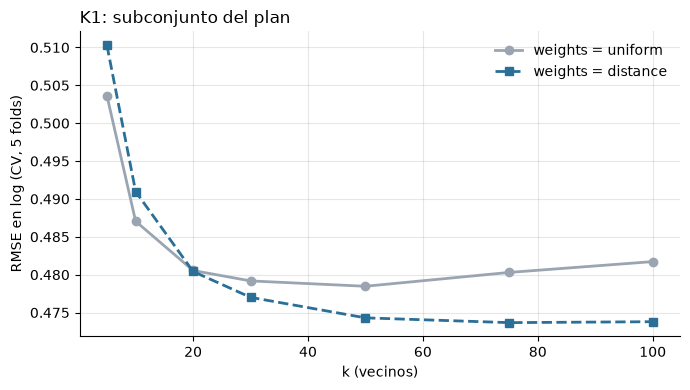

In [23]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

COLS_KNN = ['latitude', 'longitude', 'accommodates', 'bedrooms', 'room_type']
filas_knn = []
for k in [5, 10, 20, 30, 50, 75, 100]:
    for pesos in ['uniform', 'distance']:
        exp = Experimento(f'K1_knn_subconjunto_k{k}_{pesos}',
                          make_pipeline(preprocesador_lineal(COLS_KNN), KNeighborsRegressor(k, weights=pesos)),
                          COLS_KNN)
        res = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO)
        filas_knn.append({'variante': 'K1 subconjunto', 'k': k, 'weights': pesos, 'componentes': np.nan,
                          'experimento': exp.nombre, 'rmse_log_val': res['rmse_log_val'].mean(),
                          'rmse_log_val_sd': res['rmse_log_val'].std(), 'rmse_log_train': res['rmse_log_train'].mean()})
tabla_k1 = pd.DataFrame(filas_knn)

fig, ax = plt.subplots(figsize=(7, 4))
for pesos, estilo in zip(['uniform', 'distance'], ['o-', 's--']):
    d = tabla_k1.query('weights == @pesos')
    ax.plot(d['k'], d['rmse_log_val'], estilo, color=COLOR_BASE if pesos == 'distance' else COLOR_SECUNDARIO,
            lw=2, ms=6, label=f'weights = {pesos}')
ax.set_xlabel('k (vecinos)')
ax.set_ylabel('RMSE en log (CV, 5 folds)')
ax.set_title('K1: subconjunto del plan', loc='left')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### K2 y K3: FAMD y PCAmix

**Por qué:** la PCA trata una binaria o una columna one-hot como una numérica más. FAMD y PCAmix son la PCA para tablas mixtas: cada variable cualitativa aporta una inercia igual a su número de modalidades menos una, y cada modalidad pesa más cuanto más rara es.

**Entrada:** `PreparadorMixto` deja las numéricas como en el lineal (barrio con `TargetEncoder`, estancia en log, mediana en los nulos) y pasa las categóricas, las binarias y los indicadores de nulo a texto, para que FAMD/PCAmix las traten como cualitativas.

Tabla mixta: 9 numéricas y 64 categóricas (152 modalidades) -> 161 dimensiones
Regla del 80%: 51 componentes (80.3%)


|correlación| entre cada componente de FAMD y la de PCAmix en el train: mínimo 0.102887
Inercia por componente igual en los dos: False


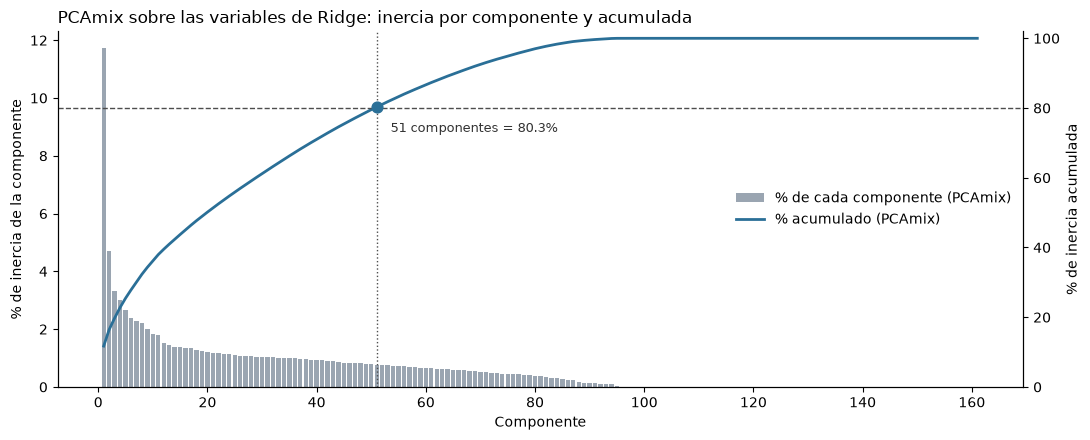

,PC1,PC2,PC3
0,am_refrigerator (6%),property_type_grp (12%),property_type_grp (9%)
1,am_dishes_and_silverware (6%),neighbourhood (10%),host_response_time (8%)
2,am_cooking_basics (6%),district (9%),host_response_rate_nulo (7%)
3,am_stove (6%),room_type (9%),am_oven (4%)
4,am_oven (5%),longitude (9%),am_stove (4%)
5,am_microwave (5%),dist_centro_km (7%),host_response_rate (4%)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
correlación con log(price),-0.1,-0.615,0.181,-0.235,0.11,0.022,0.077,-0.149,0.057,-0.091


In [24]:
# Numero de componentes de K2 y K3 (el minimo que explica al menos el 80% de la inercia)
VARIANZA_MINIMA = 0.80

tabla_mixta = PreparadorMixto(VARS_RIDGE).fit_transform(train[VARS_RIDGE], train[TARGET])
pcamix_diag = PCAmix().fit(tabla_mixta)
inercia = pcamix_diag.explained_variance_ratio_
inercia_acumulada = np.cumsum(inercia)
N_COMPONENTES_MIXTO = int(np.argmax(inercia_acumulada >= VARIANZA_MINIMA)) + 1
n_categoricas = tabla_mixta.shape[1] - len(pcamix_diag.numericas_)
print(f"Tabla mixta: {len(pcamix_diag.numericas_)} numéricas y {n_categoricas} categóricas "
      f"({len(pcamix_diag.modalidades_)} modalidades) -> {len(inercia)} dimensiones")
print(f"Regla del {VARIANZA_MINIMA:.0%}: {N_COMPONENTES_MIXTO} componentes ({inercia_acumulada[N_COMPONENTES_MIXTO - 1]:.1%})")


# FAMD (prince) y PCAmix tienen que dar las mismas componentes en el train, salvo el signo
famd_diag = FAMDPrince(N_COMPONENTES_MIXTO).fit(tabla_mixta)
coord_famd = famd_diag.transform(tabla_mixta)
coord_pcamix = pcamix_diag.transform(tabla_mixta)[:, :N_COMPONENTES_MIXTO]
coincidencia = [abs(np.corrcoef(coord_famd[:, i], coord_pcamix[:, i])[0, 1]) for i in range(N_COMPONENTES_MIXTO)]
print(f"|correlación| entre cada componente de FAMD y la de PCAmix en el train: mínimo {min(coincidencia):.6f}")
print(f"Inercia por componente igual en los dos: "
      f"{np.allclose(famd_diag.famd_.percentage_of_variance_ / 100, inercia[:N_COMPONENTES_MIXTO], atol=1e-4)}")

fig, ax = plt.subplots(figsize=(11, 4.5))
posiciones = np.arange(1, len(inercia) + 1)
ax.bar(posiciones, inercia * 100, color=COLOR_SECUNDARIO, width=0.8, label='% de cada componente (PCAmix)')
ax.set_xlabel('Componente')
ax.set_ylabel('% de inercia de la componente')
ax2 = ax.twinx()
ax2.plot(posiciones, inercia_acumulada * 100, '-', color=COLOR_BASE, lw=2, label='% acumulado (PCAmix)')
ax2.axhline(VARIANZA_MINIMA * 100, color='0.3', ls='--', lw=1)
ax2.axvline(N_COMPONENTES_MIXTO, color='0.3', ls=':', lw=1)
ax2.scatter(N_COMPONENTES_MIXTO, inercia_acumulada[N_COMPONENTES_MIXTO - 1] * 100, s=60, color=COLOR_BASE, zorder=5)
ax2.annotate(f'{N_COMPONENTES_MIXTO} componentes = {inercia_acumulada[N_COMPONENTES_MIXTO - 1]:.1%}',
             (N_COMPONENTES_MIXTO, inercia_acumulada[N_COMPONENTES_MIXTO - 1] * 100), xytext=(10, -18),
             textcoords='offset points', fontsize=9, color='0.2')
ax2.set_ylim(0, 102)
ax2.set_ylabel('% de inercia acumulada')
ax.set_title('PCAmix sobre las variables de Ridge: inercia por componente y acumulada', loc='left')
lineas = ax.get_legend_handles_labels()
lineas2 = ax2.get_legend_handles_labels()
ax.legend(lineas[0] + lineas2[0], lineas[1] + lineas2[1], frameon=False, loc='center right')
ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

# Que recogen las primeras componentes: parte de cada una que aporta cada variable (suma de cargas al cuadrado)
variable_de_columna = pcamix_diag.numericas_ + [col for col, _ in pcamix_diag.modalidades_]
aportes = pd.DataFrame(pcamix_diag.components_[:3].T ** 2, columns=['PC1', 'PC2', 'PC3']).groupby(
    variable_de_columna).sum()
display(pd.DataFrame({pc: [f'{var} ({peso:.0%})' for var, peso in aportes[pc].nlargest(6).items()]
                      for pc in aportes}))
correlaciones_mixto = pd.Series([np.corrcoef(coord_pcamix[:, i], train[TARGET])[0, 1] for i in range(10)],
                                index=[f'PC{i + 1}' for i in range(10)])
display(correlaciones_mixto.round(3).to_frame('correlación con log(price)').T)

In [25]:
for variante in REDUCTORES_MIXTOS:
    for k in [10, 20, 50]:
        exp = knn_mixto(variante, k, N_COMPONENTES_MIXTO, VARS_RIDGE)
        filas_knn.append(fila_knn(variante, k, N_COMPONENTES_MIXTO, exp, evaluar_registrado(exp, train, FOLDS_MODELOS,
                                                                                            RUTA_REGISTRO)))

tabla_knn = pd.DataFrame(filas_knn)
mejores_knn = tabla_knn.loc[tabla_knn.groupby('variante')['rmse_log_val'].idxmin()].sort_values('rmse_log_val')
display(tabla_knn.query("variante != 'K1 subconjunto'").round(4))
display(mejores_knn.round(4))

# Comparaciones pareadas con los mismos folds. Delta positivo = gana el primero
mejor_de = mejores_knn.set_index('variante')['experimento']
pares_knn = {
    'K3 PCAmix frente a K2 FAMD': ('K3 PCAmix', 'K2 FAMD'),
    'K3 PCAmix frente a K1 subconjunto': ('K3 PCAmix', 'K1 subconjunto'),
    'K2 FAMD frente a K1 subconjunto': ('K2 FAMD', 'K1 subconjunto'),
}
comparaciones_knn = {nombre: comparar_pareado(filas_registro(mejor_de[a], RUTA_REGISTRO), filas_registro(mejor_de[b], RUTA_REGISTRO))
                     for nombre, (a, b) in pares_knn.items()}
display(pd.DataFrame(comparaciones_knn).T)

,variante,k,weights,componentes,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train
14,K2 FAMD,10,distance,51.0,K2_knn_famd51_k10,0.4888,0.0120,0.0490
15,K2 FAMD,20,distance,51.0,K2_knn_famd51_k20,0.4820,0.0104,0.0690
16,K2 FAMD,50,distance,51.0,K2_knn_famd51_k50,0.4847,0.0110,0.1108
17,K3 PCAmix,10,distance,51.0,K3_knn_pcamix51_k10,0.4892,0.0113,0.0493
18,K3 PCAmix,20,distance,51.0,K3_knn_pcamix51_k20,0.4817,0.0116,0.0691
19,K3 PCAmix,50,distance,51.0,K3_knn_pcamix51_k50,0.4842,0.0110,0.1110


,variante,k,weights,componentes,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train
11,K1 subconjunto,75,distance,NaN,K1_knn_subconjunto_k75_distance,0.4737,0.0120,0.0224
18,K3 PCAmix,20,distance,51.0,K3_knn_pcamix51_k20,0.4817,0.0116,0.0691
15,K2 FAMD,20,distance,51.0,K2_knn_famd51_k20,0.4820,0.0104,0.0690


,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
K3 PCAmix frente a K2 FAMD,0.000272,0.001794,2/5,0.416168,False
K3 PCAmix frente a K1 subconjunto,-0.008063,0.004436,0/5,0.97322,False
K2 FAMD frente a K1 subconjunto,-0.008335,0.003299,0/5,0.990171,False


#### Conclusiones:
**FAMD y PCAmix dan el mismo resultado, y ninguno de los dos supera al kNN con cinco variables elegidas por conocimiento del dominio (K1).**

- **Reducción:** con la regla del 80% de la inercia, las 71 variables de Ridge se quedan en
  **51 componentes**. En el train, FAMD (`prince`) y PCAmix dan las mismas componentes y la misma inercia por componente: son el mismo método.
- **FAMD frente a PCAmix (observado):** mejor k = 20 en los dos, **son indistinguibles**. 
- **Frente a K1:** K1 (lat/lon, capacidad, dormitorios y `room_type`; k = 75) llega a **0,4737**, y gana a K3 y a K4 por **Δ ≈ 0,008 en 5 de 5 folds** (p = 0,03 y 0,01).
- **Interpretación:** en kNN todas las dimensiones pesan en la distancia. Las 51 componentes reparten la inercia entre amenities y perfil del anfitrión, que apenas dicen qué anuncios son comparables en precio, y diluyen lo que sí lo dice: ubicación y tamaño. K1 fija esa información a mano.
- **Qué pasa a la comparativa:** K1 y el mejor de los dos mixtos (**PCAmix, K3**). Se descartan búsquedas de variables para kNN (*wrappers*) por coste.


### 8.2 CART

Un solo árbol parte los anuncios con reglas "si... entonces". **Hiperparámetros:** `max_depth` (cuántas
preguntas seguidas) y `min_samples_leaf` (cuántos anuncios como mínimo en cada hoja). Árbol profundo con hojas
pequeñas = poco sesgo y mucha varianza. Dos usos: un árbol de profundidad 3 para enseñar las reglas al
sponsor, y el árbol ajustado para la métrica. Usa las 79 variables con codificación ordinal (sin
`TargetEncoder`, para que las reglas se lean).

In [26]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

filas_arbol = []
for profundidad in [3, 5, 8, 10, 12, 15, 20]:
    for hoja in [5, 20, 50, 100, 200]:
        exp = Experimento(f'T_arbol_d{profundidad}_hoja{hoja}',
                          make_pipeline(preprocesador_ordinal(COLS_B),
                                        DecisionTreeRegressor(max_depth=profundidad, min_samples_leaf=hoja,
                                                              random_state=SEMILLA)),
                          COLS_B)
        res = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO)
        filas_arbol.append({'max_depth': profundidad, 'min_samples_leaf': hoja, 'experimento': exp.nombre,
                            'rmse_log_val': res['rmse_log_val'].mean(), 'rmse_log_val_sd': res['rmse_log_val'].std(),
                            'rmse_log_train': res['rmse_log_train'].mean()})
tabla_arbol = pd.DataFrame(filas_arbol)
mejor_arbol = tabla_arbol.loc[tabla_arbol['rmse_log_val'].idxmin()]
display(tabla_arbol.pivot(index='max_depth', columns='min_samples_leaf', values='rmse_log_val').round(4))
print(f"Mejor árbol: max_depth={mejor_arbol['max_depth']}, min_samples_leaf={mejor_arbol['min_samples_leaf']} "
      f"-> RMSE {mejor_arbol['rmse_log_val']:.4f} ± {mejor_arbol['rmse_log_val_sd']:.4f} (train {mejor_arbol['rmse_log_train']:.4f})")

min_samples_leaf,5,20,50,100,200
max_depth,,,,,
3,0.5267,0.5267,0.5267,0.5267,0.5261
5,0.4997,0.5002,0.4985,0.4978,0.4993
8,0.4833,0.4774,0.4751,0.4773,0.4827
10,0.4913,0.4770,0.4719,0.4748,0.4808
12,0.5069,0.4803,0.4725,0.4748,0.4808
15,0.5222,0.4856,0.4733,0.4747,0.4808
20,0.5449,0.4874,0.4734,0.4747,0.4808


Mejor árbol: max_depth=10, min_samples_leaf=50 -> RMSE 0.4719 ± 0.0138 (train 0.4265)


#### Poda por coste-complejidad con la regla de un error estándar

La rejilla anterior limita el árbol **mientras crece** (prepoda). La poda de CART hace lo contrario: deja crecer
el árbol entero y después quita las ramas que menos reducen el error. Minimiza

$$R_\alpha(T) = \text{ECM}(T) + \alpha \cdot |T|$$

donde |T| es el número de hojas: cada hoja "cuesta" α. Con α = 0 se queda el árbol entero; al subir α, el árbol
se simplifica.

**Regla de un error estándar (1-SE):** en vez del α con menor RMSE, se elige **el mayor α (el árbol más
sencillo)** cuyo RMSE medio no supere el mínimo más un error estándar (SE = desviación típica entre folds / √5).
Las diferencias dentro de un SE no se distinguen del ruido de la validación, así que se prefiere el árbol más
pequeño. En el gráfico: línea discontinua = mínimo + 1 SE; el α elegido es el punto más a la derecha por debajo
de ella.

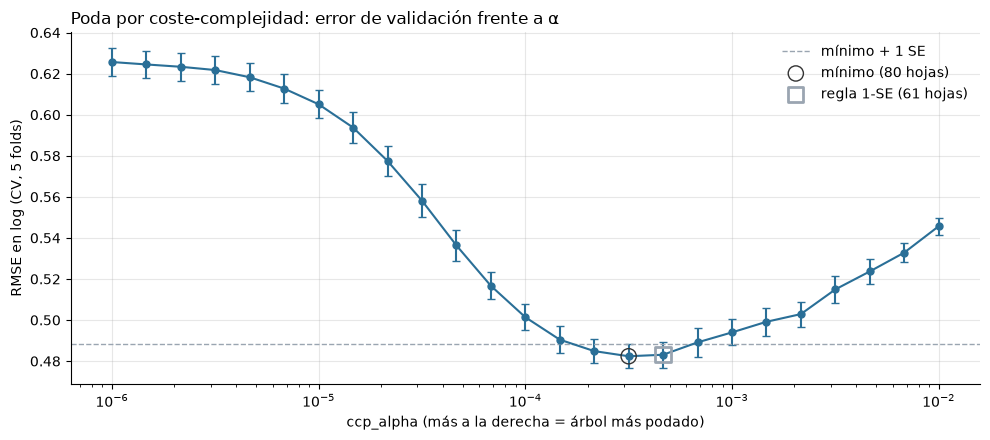

,ccp_alpha,n_hojas,rmse_log_val,se
0,0.00000,12241,0.62568,0.00667
1,0.00000,10995,0.62449,0.00673
2,0.00000,9750,0.62336,0.00684
3,0.00000,8442,0.62177,0.00692
4,0.00000,7192,0.61826,0.00685
5,0.00001,5903,0.61274,0.00702
6,0.00001,4718,0.60509,0.00693
7,0.00001,3498,0.59376,0.00769
8,0.00002,2408,0.57748,0.00722
9,0.00003,1540,0.55815,0.00816


Mínimo: alpha = 3.16e-04, 80 hojas, RMSE 0.4824
Regla 1-SE: alpha = 4.64e-04, 61 hojas, RMSE 0.4831 (umbral 0.4881)
Prepoda (rejilla anterior): RMSE 0.4719


In [27]:
ALPHAS_PODA = np.logspace(-6, -2, 25)
filas_poda = []
for alpha in ALPHAS_PODA:
    exp = Experimento(f'T_arbol_poda_ccp{alpha:.2e}',
                      make_pipeline(preprocesador_ordinal(COLS_B),
                                    DecisionTreeRegressor(ccp_alpha=alpha, random_state=SEMILLA)),
                      COLS_B)
    res = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO, paralelo=5)
    n_hojas = exp.modelo.fit(train[COLS_B], train[TARGET])[-1].get_n_leaves()
    filas_poda.append({'ccp_alpha': alpha, 'n_hojas': n_hojas, 'rmse_log_val': res['rmse_log_val'].mean(),
                       'se': res['rmse_log_val'].std() / np.sqrt(len(res)), 'experimento': exp.nombre})
tabla_poda = pd.DataFrame(filas_poda)

minimo = tabla_poda.loc[tabla_poda['rmse_log_val'].idxmin()]
umbral_1se = minimo['rmse_log_val'] + minimo['se']
poda_1se = tabla_poda[tabla_poda['rmse_log_val'] <= umbral_1se].sort_values('ccp_alpha').iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(tabla_poda['ccp_alpha'], tabla_poda['rmse_log_val'], yerr=tabla_poda['se'], fmt='o-', color=COLOR_BASE,
            lw=1.5, ms=5, capsize=3)
ax.axhline(umbral_1se, color=COLOR_SECUNDARIO, ls='--', lw=1, label='mínimo + 1 SE')
ax.scatter(minimo['ccp_alpha'], minimo['rmse_log_val'], s=120, facecolor='none', edgecolor='0.2', zorder=5,
           label=f"mínimo ({int(minimo['n_hojas'])} hojas)")
ax.scatter(poda_1se['ccp_alpha'], poda_1se['rmse_log_val'], s=120, marker='s', facecolor='none',
           edgecolor=COLOR_SECUNDARIO, lw=2, zorder=5, label=f"regla 1-SE ({int(poda_1se['n_hojas'])} hojas)")
ax.set_xscale('log')
ax.set_xlabel('ccp_alpha (más a la derecha = árbol más podado)')
ax.set_ylabel('RMSE en log (CV, 5 folds)')
ax.set_title('Poda por coste-complejidad: error de validación frente a α', loc='left')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(tabla_poda[['ccp_alpha', 'n_hojas', 'rmse_log_val', 'se']].round(5))
print(f"Mínimo: alpha = {minimo['ccp_alpha']:.2e}, {int(minimo['n_hojas'])} hojas, RMSE {minimo['rmse_log_val']:.4f}")
print(f"Regla 1-SE: alpha = {poda_1se['ccp_alpha']:.2e}, {int(poda_1se['n_hojas'])} hojas, "
      f"RMSE {poda_1se['rmse_log_val']:.4f} (umbral {umbral_1se:.4f})")
print(f"Prepoda (rejilla anterior): RMSE {mejor_arbol['rmse_log_val']:.4f}")

,fold,raiz,segundo_nivel_izq,top3_importancia,n_hojas
0,0,room_type <= 1.50,bedrooms <= 2.50,"room_type, bedrooms, longitude",219
1,1,room_type <= 1.50,bedrooms <= 2.50,"room_type, bedrooms, longitude",236
2,2,room_type <= 1.50,bedrooms <= 2.50,"room_type, bedrooms, longitude",245
3,3,room_type <= 1.50,bedrooms <= 2.50,"room_type, bedrooms, longitude",212
4,4,room_type <= 1.50,bedrooms <= 2.50,"room_type, bedrooms, longitude",219


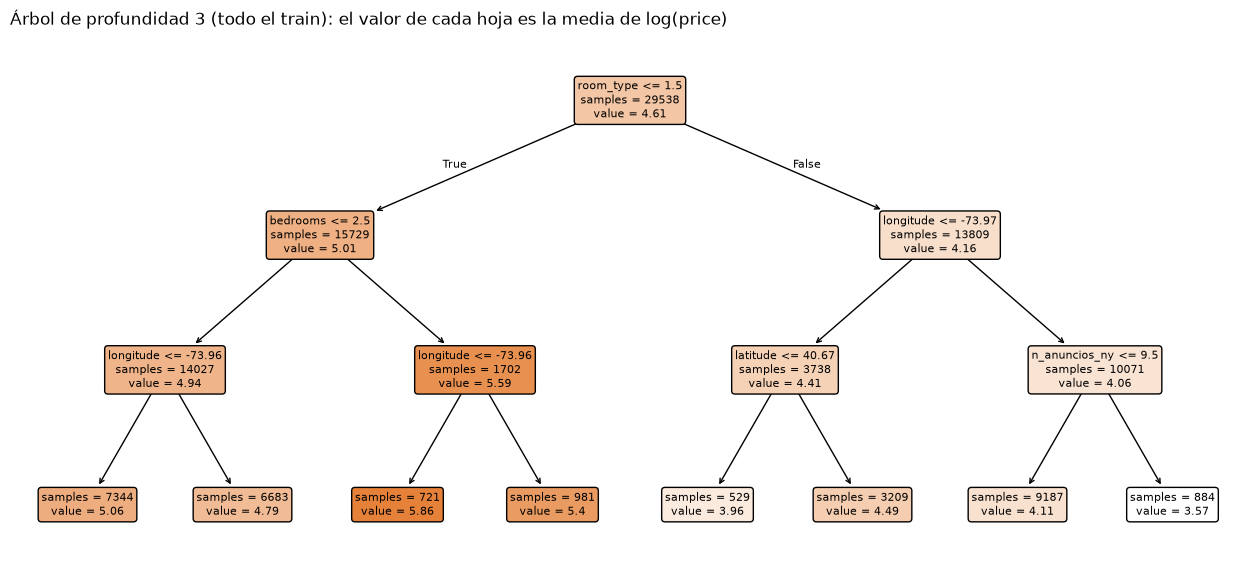

Codificación de room_type: {0: 'Entire place', 1: 'Hotel room', 2: 'Private room', 3: 'Shared room'}


In [28]:
# Inestabilidad: la primera particion y las variables mas importantes cambian de un fold a otro
estructura = []
for f in FOLDS_MODELOS:
    arbol = make_pipeline(preprocesador_ordinal(COLS_B),
                          DecisionTreeRegressor(max_depth=int(mejor_arbol['max_depth']),
                                                min_samples_leaf=int(mejor_arbol['min_samples_leaf']),
                                                random_state=SEMILLA))
    arbol.fit(train[COLS_B].iloc[f.train], train[TARGET].iloc[f.train])
    nombres = arbol[0].get_feature_names_out()
    t = arbol[-1].tree_
    importancias = pd.Series(arbol[-1].feature_importances_, index=nombres).sort_values(ascending=False)
    hijos_izq = t.children_left[0]
    estructura.append({'fold': f.fold, 'raiz': f'{nombres[t.feature[0]]} <= {t.threshold[0]:.2f}',
                       'segundo_nivel_izq': f'{nombres[t.feature[hijos_izq]]} <= {t.threshold[hijos_izq]:.2f}',
                       'top3_importancia': ', '.join(importancias.index[:3]), 'n_hojas': arbol[-1].get_n_leaves()})
display(pd.DataFrame(estructura))

arbol_3 = make_pipeline(preprocesador_ordinal(COLS_B), DecisionTreeRegressor(max_depth=3, random_state=SEMILLA))
arbol_3.fit(train[COLS_B], train[TARGET])
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(arbol_3[-1], feature_names=arbol_3[0].get_feature_names_out(), filled=True, rounded=True, fontsize=8,
          impurity=False, precision=2, ax=ax)
ax.set_title('Árbol de profundidad 3 (todo el train): el valor de cada hoja es la media de log(price)', loc='left')
plt.show()
codigos_room = arbol_3[0].named_transformers_['categoricas'].categories_[
    list(arbol_3[0].transformers_[0][2]).index('room_type')]
print('Codificación de room_type:', dict(enumerate(codigos_room)))

#### Conclusiones:
**Un solo árbol se queda en un RMSE de 0,472, por detrás del lineal (0,439), y la poda por coste-complejidad no mejora a la prepoda. La parte alta del árbol es estable entre folds.**

- **Prepoda:** el mejor árbol tiene `max_depth = 10` y `min_samples_leaf = 50`, con RMSE
  **0,4719**. 
- **Poda:** el mínimo es α = 3,2·10⁻⁴ (80 hojas, **0,4824**). La regla 1-SE elige α = 4,6·10⁻⁴
  (**61 hojas, 0,4831**): casi el mismo error con un 25% menos de hojas. Sin podar, el árbol completo
  (12.241 hojas) sobreajusta hasta 0,626.
- **Prepoda frente a poda (interpretación):** la prepoda gana por ~0,01. La poda parte de un árbol con hojas de un solo anuncio y solo puede quitar ramas; la prepoda además exige que cada hoja promedie al menos 50 anuncios, y su predicción es más estable. La rejilla de α (25 valores) es gruesa, así que el mínimo de la poda es aproximado.
- **Estructura (observado):** en los 5 folds, la raíz es la misma (`room_type`: piso entero u hotel frente a habitación privada o compartida), el segundo nivel también (`bedrooms ≤ 2,5`) y las tres variables más importantes coinciden (`room_type`, `bedrooms`, `longitude`). Solo cambia el número de hojas (212-245). **La inestabilidad típica del árbol no aparece arriba**, donde mandan las variables con más señal. Si existe, está en los niveles profundos, que esta tabla no muestra.


## 9. ENSEMBLES (NIVEL 3)

### 9.1 Random Forest y HGB por defecto

- **Random Forest** (bagging): promedia 500 árboles profundos, cada uno entrenado con una muestra *bootstrap*
  y un subconjunto aleatorio de variables en cada corte. **Reduce varianza.** El error OOB no se usa porque
  ignora los grupos por anfitrión (un gemelo del anuncio suele estar en la muestra *bootstrap*).
- **HGB** (boosting): suma árboles pequeños, cada uno corrigiendo los errores de los anteriores. **Reduce
  sesgo.** Categóricas y nulos nativos.

Punto de partida para el ajuste (sección 9.3): RF con `max_features = 0,33` (la recomendación clásica para
regresión es p/3) y HGB por defecto.

In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

HGB_POR_DEFECTO = dict(max_iter=300, learning_rate=0.1, early_stopping=False, random_state=SEMILLA)


rf_base = Experimento('RF_base', make_pipeline(preprocesador_ordinal(COLS_B),
                                               RandomForestRegressor(n_estimators=500, max_features=0.33,
                                                                     n_jobs=-1, random_state=SEMILLA)),
                      COLS_B)
hgb_base = Experimento('HGB_base', make_pipeline(preprocesador_arboles(COLS_B),
                                                 HistGradientBoostingRegressor(**HGB_POR_DEFECTO)), COLS_B)
resultados_ens = pd.concat([evaluar_registrado(e, train, FOLDS_MODELOS, RUTA_REGISTRO) for e in [rf_base, hgb_base]])
display(resumir(resultados_ens)[['rmse_log_val_mean', 'rmse_log_val_std', 'rmse_log_train_mean', 'mae_usd_val_mean',
                                 't_ajuste_s_mean']].round(4))

,rmse_log_val_mean,rmse_log_val_std,rmse_log_train_mean,mae_usd_val_mean,t_ajuste_s_mean
experimento,,,,,
RF_base,0.4286,0.0119,0.1444,48.9259,12.4442
HGB_base,0.4233,0.0097,0.3073,48.3089,2.8879


### 9.2 Codificación del barrio en HGB

Decisión técnica con tres alternativas:

| Variante | Cómo | A favor | En contra |
|---|---|---|---|
| (a) Fuera | Sin `neighbourhood`; la ubicación la llevan lat/lon, distancia y distrito | Simple, sin riesgo de sobreajuste | Pierde la etiqueta administrativa |
| (b) `TargetEncoder` | Media del target por barrio, suavizada y con *cross-fitting* | Una sola columna; maneja barrios pequeños | El *cross-fitting* interno es por filas, no por anfitrión, así que un anuncio puede ver el precio de su gemelo de cartera |
| (c) Categórica nativa | HGB busca la mejor partición de las 219 categorías | Sin paso previo | Con 106 barrios de N < 30, riesgo de sobreajuste |

In [30]:
variantes_barrio = {
    'HGB_barrio_fuera': (sin(COLS_B, ['neighbourhood']), 'target'),
    'HGB_barrio_target': (COLS_B, 'target'),
    'HGB_barrio_nativa': (COLS_B, 'nativa'),
}
resultados_barrio = {}
for nombre, (columnas, codificacion) in variantes_barrio.items():
    exp = Experimento(nombre, make_pipeline(preprocesador_arboles(columnas, barrio=codificacion),
                                            HistGradientBoostingRegressor(**HGB_POR_DEFECTO)), columnas)
    resultados_barrio[nombre] = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO)
display(resumir(pd.concat(resultados_barrio.values()))[['rmse_log_val_mean', 'rmse_log_val_std', 'rmse_log_train_mean']].round(4))
display(pd.DataFrame({
    'target frente a fuera': comparar_pareado(resultados_barrio['HGB_barrio_target'], resultados_barrio['HGB_barrio_fuera']),
    'nativa frente a fuera': comparar_pareado(resultados_barrio['HGB_barrio_nativa'], resultados_barrio['HGB_barrio_fuera']),
    'nativa frente a target': comparar_pareado(resultados_barrio['HGB_barrio_nativa'], resultados_barrio['HGB_barrio_target']),
}).T)

,rmse_log_val_mean,rmse_log_val_std,rmse_log_train_mean
experimento,,,
HGB_barrio_fuera,0.4263,0.0117,0.3058
HGB_barrio_target,0.4233,0.0097,0.3073
HGB_barrio_nativa,0.4253,0.0080,0.2935


,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
target frente a fuera,0.002945,0.004588,3/5,0.196402,False
nativa frente a fuera,0.000996,0.005126,3/5,0.393245,False
nativa frente a target,-0.001949,0.002026,1/5,0.88762,False


#### Conclusiones:
**Cómo se codifique el barrio no cambia el resultado.**

- **RF frente a HGB:** HGB por defecto llega a **0,4233** (MAE $48,3) y RF a **0,4286** ($48,9).
- **Sobreajuste (observado e interpretado):** RF baja a 0,144 en train y HGB a 0,307. La distancia de RF es
  esperable: sus árboles crecen sin límite y casi memorizan el train. Que generalice igual de bien lo hace el promedio de 500 árboles, no cada árbol.
- **Codificación del barrio en HGB (observado):** `TargetEncoder` **0,4233**, categórica nativa **0,4253**, sin barrio **0,4263**. Ninguna diferencia pasa la regla: *target* frente a fuera, Δ = 0,0029 en 3 de 5 folds (p = 0,20); nativa frente a fuera, Δ = 0,0010 en 3 de 5 (p = 0,39); nativa frente a *target*, −0,0019 en 1 de 5 (p = 0,89).
- **Interpretación:** con lat/lon, distancia al centro y distrito, el barrio apenas añade información a HGB. La nativa es la que más se ajusta al train (0,294 frente a 0,307 del *target*) sin ganar en validación: con 219 categorías, muchas pequeñas.
- **Decisión:** se mantiene el `TargetEncoder`, porque ninguna alternativa le gana.

### 9.3 Ajuste de hiperparámetros de RF y HGB

**Método:** búsqueda aleatoria con `buscar` (sección 7.4) sobre **las 79 variables** y los mismos 5 folds (repetición 0),
agrupados por anfitrión. Cada candidato queda en `outputs/experimentos.csv` con sus métricas fold a fold.

| Modelo | Espacio (plan de modelado, sección 7) | Qué controla cada hiperparámetro |
|---|---|---|
| RF | `max_features` {0,2; 0,33; 0,5; 1,0}; `min_samples_leaf` {1, 3, 5, 10, 20}; `max_depth` {None, 15, 25}; 30 combinaciones | `max_features` descorrelaciona los árboles (menos varianza del promedio); hojas y profundidad limitan cada árbol |
| HGB | `learning_rate` log [0,02, 0,2]; `max_iter` [200, 2000]; `max_leaf_nodes` [15, 127]; `min_samples_leaf` [10, 200]; `l2_regularization` log [1e-3, 10]; `max_features` [0,3, 1]; 40 combinaciones | `learning_rate` × `max_iter`: cuánto se corrige en cada paso y cuántos pasos (poco ritmo y muchos pasos generaliza mejor, pero cuesta más); hojas y regularización: complejidad de cada árbol |

En RF, `n_estimators = 150` durante la búsqueda: el número de árboles no sobreajusta, solo estabiliza la media,
y a partir de unos cientos apenas cambia el error. El candidato elegido se reevalúa con 500.

**Aviso para la memoria:** el RMSE de CV del mejor candidato es **optimista**, porque se ha elegido mirando esos
mismos folds (sesgo de selección). Con 40 candidatos el sesgo puede ser del orden de la desviación entre folds.
Por eso existe el test.

In [31]:
busqueda_rf = buscar('T7_rf', lambda nombre, p: construir_rf(nombre, p, COLS_B), {'max_features': [0.2, 0.33, 0.5, 1.0],
                                             'min_samples_leaf': [1, 3, 5, 10, 20],
                                             'max_depth': [None, 15, 25]}, 30)
display(busqueda_rf.head(8).round(4))

,min_samples_leaf,max_features,max_depth,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train,t_ajuste_s
10,3,0.33,25.0,T7_rf_10,0.4288,0.0117,0.2420,2.6665
3,1,0.33,25.0,T7_rf_03,0.4288,0.0121,0.1520,3.6840
0,1,0.20,NaN,T7_rf_00,0.4294,0.0122,0.1462,2.5253
17,3,0.33,NaN,T7_rf_17,0.4295,0.0125,0.2412,3.0408
24,1,0.33,15.0,T7_rf_24,0.4298,0.0121,0.2500,2.6004
1,1,0.33,NaN,T7_rf_01,0.4298,0.0118,0.1461,4.0142
12,3,0.50,15.0,T7_rf_12,0.4298,0.0118,0.2800,4.0013
27,5,0.33,15.0,T7_rf_27,0.4298,0.0129,0.3124,2.4498


In [32]:
ESPACIO_HGB = {'learning_rate': loguniform(0.02, 0.2), 'max_iter': randint(200, 2001),
               'max_leaf_nodes': randint(15, 128), 'min_samples_leaf': randint(10, 201),
               'l2_regularization': loguniform(1e-3, 10), 'max_features': uniform(0.3, 0.7)}
busqueda_hgb = buscar('T7_hgb', lambda nombre, p: construir_hgb(nombre, p, COLS_B), ESPACIO_HGB, 40)
display(busqueda_hgb.head(8).round(4))

,l2_regularization,learning_rate,max_features,max_iter,max_leaf_nodes,min_samples_leaf,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train,t_ajuste_s
30,0.1025,0.0225,0.4951,1448,15,156,T7_hgb_30,0.4191,0.0099,0.3579,7.0326
9,4.3379,0.0363,0.7638,1225,20,63,T7_hgb_09,0.4192,0.0096,0.3247,8.4127
32,0.0021,0.0468,0.4695,493,38,78,T7_hgb_32,0.4194,0.0113,0.3249,4.8137
20,0.0013,0.0866,0.5200,295,18,160,T7_hgb_20,0.4201,0.0085,0.3595,1.2939
18,0.0774,0.0263,0.7993,1992,19,151,T7_hgb_18,0.4205,0.0110,0.3273,14.7322
36,5.7822,0.0500,0.6624,1071,15,20,T7_hgb_36,0.4205,0.0098,0.3280,4.3828
2,0.6797,0.0210,0.9789,1715,44,47,T7_hgb_02,0.4215,0.0126,0.2793,21.2619
25,0.0082,0.0535,0.8726,1968,17,112,T7_hgb_25,0.4227,0.0087,0.2952,7.4817


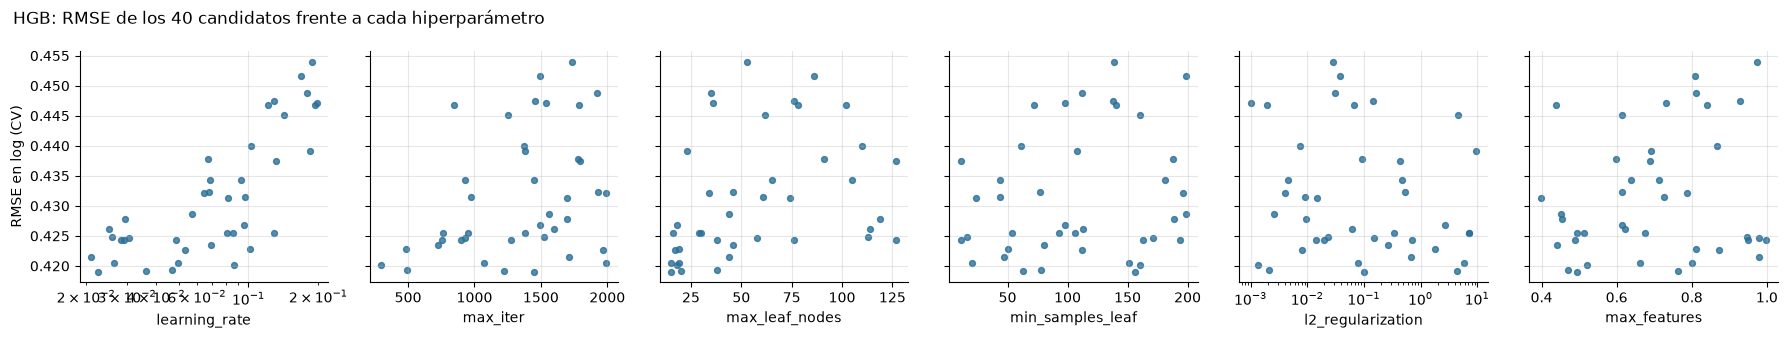

In [33]:
# Que hiperparametros importan: RMSE de cada candidato frente a cada hiperparametro
fig, ejes = plt.subplots(1, 6, figsize=(18, 3.4), sharey=True)
for eje, param in zip(ejes, ESPACIO_HGB):
    eje.scatter(busqueda_hgb[param], busqueda_hgb['rmse_log_val'], color=COLOR_BASE, s=18, alpha=0.8)
    if param in ('learning_rate', 'l2_regularization'):
        eje.set_xscale('log')
    eje.set_xlabel(param)
    eje.grid(alpha=0.3)
    eje.spines[['top', 'right']].set_visible(False)
ejes[0].set_ylabel('RMSE en log (CV)')
fig.suptitle(f'HGB: RMSE de los {len(busqueda_hgb)} candidatos frente a cada hiperparámetro', x=0.01, ha='left')
plt.tight_layout()
plt.show()

In [34]:
MEJOR_RF = busqueda_rf.iloc[0]
MEJOR_HGB = busqueda_hgb.iloc[0]
PARAMS_RF = {k: (None if pd.isna(MEJOR_RF[k]) else MEJOR_RF[k]) for k in ['max_features', 'min_samples_leaf', 'max_depth']}
PARAMS_RF['min_samples_leaf'] = int(PARAMS_RF['min_samples_leaf'])
PARAMS_RF['max_depth'] = None if PARAMS_RF['max_depth'] is None else int(PARAMS_RF['max_depth'])
PARAMS_HGB = {k: MEJOR_HGB[k] for k in ESPACIO_HGB}
for k in ['max_iter', 'max_leaf_nodes', 'min_samples_leaf']:
    PARAMS_HGB[k] = int(PARAMS_HGB[k])
print('RF elegido:', PARAMS_RF)
print('HGB elegido:', {k: round(v, 4) if isinstance(v, float) else v for k, v in PARAMS_HGB.items()})

rf_final = evaluar_registrado(construir_rf('RF_ajustado', PARAMS_RF, COLS_B, n_estimators=500), train, FOLDS_MODELOS,
                              RUTA_REGISTRO)
hgb_final = evaluar_registrado(construir_hgb('HGB_ajustado', PARAMS_HGB, COLS_B), train, FOLDS_MODELOS, RUTA_REGISTRO)
display(resumir(pd.concat([resultados_ens, rf_final, hgb_final]))[
    ['rmse_log_val_mean', 'rmse_log_val_std', 'rmse_log_train_mean', 'mae_usd_val_mean', 't_ajuste_s_mean']].round(4))
# Delta positivo = gana el primero
display(pd.DataFrame({
    'RF_ajustado frente a RF_base': comparar_pareado(rf_final, resultados_ens.query("experimento == 'RF_base'")),
    'HGB_ajustado frente a HGB_base': comparar_pareado(hgb_final, resultados_ens.query("experimento == 'HGB_base'")),
    'HGB_ajustado frente a RF_ajustado': comparar_pareado(hgb_final, rf_final),
}).T)

RF elegido: {'max_features': np.float64(0.33), 'min_samples_leaf': 3, 'max_depth': 25}
HGB elegido: {'learning_rate': np.float64(0.0225), 'max_iter': 1448, 'max_leaf_nodes': 15, 'min_samples_leaf': 156, 'l2_regularization': np.float64(0.1025), 'max_features': np.float64(0.4951)}


,rmse_log_val_mean,rmse_log_val_std,rmse_log_train_mean,mae_usd_val_mean,t_ajuste_s_mean
experimento,,,,,
RF_base,0.4286,0.0119,0.1444,48.9259,12.4442
HGB_base,0.4233,0.0097,0.3073,48.3089,2.8879
RF_ajustado,0.4278,0.0119,0.2412,48.8277,7.5526
HGB_ajustado,0.4191,0.0099,0.3579,48.1328,7.6982


,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
RF_ajustado frente a RF_base,0.000809,0.000419,5/5,0.022528,True
HGB_ajustado frente a HGB_base,0.004245,0.002133,5/5,0.020644,True
HGB_ajustado frente a RF_ajustado,0.00873,0.002818,5/5,0.004949,True


#### Conclusiones:
**Ajustar mejora a los dos ensembles, pero mucho más a HGB: HGB ajustado (0,4191) gana a RF ajustado (0,4278) en los 5 folds, y esa es ya una comparación entre los modelos que se van a usar.**

- **HGB:** el mejor candidato es `learning_rate` 0,0225, `max_iter` 1.448, `max_leaf_nodes` 15, `min_samples_leaf` 156, `l2_regularization` 0,10 y `max_features` 0,50. RMSE **0,4191** frente a 0,4233 por defecto: **Δ = 0,0042 en 5 de 5 folds** (p = 0,02).
- **El óptimo es plano:** los seis mejores candidatos quedan entre 0,4191 y 0,4205 con configuraciones muy distintas.  Lo que comparten casi todos es **árboles pequeños** (15-20 hojas, salvo uno de 38) y **`max_features` < 0,8**.
- **Interpretación:** HGB gana con muchos árboles pequeños y regularizados, que corrigen poco en cada paso. Por eso el ajustado se pega menos al train que el de por defecto (0,358 frente a 0,307) y generaliza mejor. Como el óptimo es plano, el RMSE del ganador es algo optimista (sesgo de selección entre 40 candidatos).
- **Coste:** el ganador tarda **7,0 s** por fold. `T7_hgb_20` llega a 0,4201 en **1,3 s**: un 0,1% más de error con cinco veces menos tiempo. Se podria elegir cualquiera de las dos segun convenga.
- **RF :** llega a **0,4278** frente a 0,4286 por defecto. El RF por defecto ya estaba cerca  de su techo.


## 10. CUANTÍLICA, SVR Y CATBOOST

### 10.1 Regresión cuantílica con HGB: un rango de precio, no un número

Se ajustan tres HGB con `loss = 'quantile'` para los cuantiles 0,1, 0,5 y 0,9, con los hiperparámetros y las 79 variables del HGB
ajustado. El intervalo [q0,1, q0,9] debería contener el precio real el **80%** de las veces. Se mide la
**cobertura real** en validación, la anchura mediana del intervalo (en log y en dólares), la *pinball loss* de
cada cuantil (la pérdida que minimiza cada modelo) y cuántas veces se cruzan los cuantiles (q0,1 > q0,9), que
puede pasar porque los tres modelos se ajustan por separado.

In [35]:
modelos_cuantil = {alfa: construir_hgb('tmp', {**PARAMS_HGB, 'loss': 'quantile', 'quantile': alfa}, COLS_B).modelo
                   for alfa in [0.1, 0.5, 0.9]}
RUTA_CUANTILES = OUTPUT_DIR / 'cuantiles.csv'
if RUTA_CUANTILES.exists():
    resultados_cuantil = pd.read_csv(RUTA_CUANTILES)
else:
    resultados_cuantil = evaluar_intervalo('Q8_hgb_cuantilico', modelos_cuantil, COLS_B, train, FOLDS_MODELOS)
    resultados_cuantil.to_csv(RUTA_CUANTILES, index=False)
display(resultados_cuantil.round(4))
resumen_cuantil = resultados_cuantil.drop(columns=['experimento', 'repeticion', 'fold']).agg(['mean', 'std'])
display(resumen_cuantil.round(4))


,experimento,repeticion,fold,cobertura_nominal,cobertura,cuantiles_cruzados,anchura_log_mediana,anchura_usd_mediana,pinball_0.1,pinball_0.5,pinball_0.9
0,Q8_hgb_cuantilico,0,0,0.8,0.7286,0.0000,0.8087,79.5924,0.0659,0.1537,0.0795
1,Q8_hgb_cuantilico,0,1,0.8,0.7178,0.0008,0.8183,80.0359,0.0683,0.1591,0.0857
2,Q8_hgb_cuantilico,0,2,0.8,0.7307,0.0024,0.8111,80.7550,0.0686,0.1516,0.0808
3,Q8_hgb_cuantilico,0,3,0.8,0.7404,0.0000,0.8135,78.9131,0.0610,0.1506,0.0823
4,Q8_hgb_cuantilico,0,4,0.8,0.7237,0.0000,0.8148,78.5630,0.0661,0.1506,0.0800


,cobertura_nominal,cobertura,cuantiles_cruzados,anchura_log_mediana,anchura_usd_mediana,pinball_0.1,pinball_0.5,pinball_0.9
mean,0.8,0.7282,0.0006,0.8133,79.5719,0.066,0.1531,0.0816
std,0.0,0.0084,0.0010,0.0037,0.8757,0.003,0.0036,0.0025


In [36]:
# Cobertura por segmento en el ultimo fold: el intervalo tiene que valer tambien para los pisos caros
f = FOLDS_MODELOS[-1]
pred_q = {alfa: clone(m).fit(train[COLS_B].iloc[f.train], train[TARGET].iloc[f.train])
          .predict(train[COLS_B].iloc[f.validacion]) for alfa, m in modelos_cuantil.items()}
validacion = train.iloc[f.validacion].assign(q10=pred_q[0.1], q50=pred_q[0.5], q90=pred_q[0.9])
validacion['dentro'] = (validacion[TARGET] >= validacion['q10']) & (validacion[TARGET] <= validacion['q90'])
validacion['quintil_precio'] = pd.qcut(validacion['price'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
display(pd.concat({
    'room_type': validacion.groupby('room_type', observed=True)['dentro'].agg(['mean', 'size']),
    'district': validacion.groupby('district', observed=True)['dentro'].agg(['mean', 'size']),
    'quintil de precio': validacion.groupby('quintil_precio', observed=True)['dentro'].agg(['mean', 'size']),
}).rename(columns={'mean': 'cobertura', 'size': 'n'}).round(3))

cobertura     n
room_type         Entire place       0.722  3104
                  Hotel room         0.805    41
                  Private room       0.725  2653
                  Shared room        0.694   108
district          Bronx              0.778   158
                  Brooklyn           0.738  2313
                  Manhattan          0.712  2638
                  Queens             0.710   751
                  Staten Island      0.674    46
quintil de precio Q1                 0.631  1243
                  Q2                 0.772  1168
                  Q3                 0.767  1154
                  Q4                 0.812  1161
                  Q5                 0.644  1180

#### Conclusiones:
**El intervalo [q0,1; q0,9] cubre el precio real el 72,8% de las veces, no el 80% prometido, y falla sobre todo en los extremos de precio.**

- **Cobertura:** **72,8% ± 0,8** frente al 80% nominal, entre 71,8% y 74,0% según el fold. La falta de cobertura es sistemática, no ruido. Anchura mediana del intervalo: **0,81 en log, unos $80**. Los cuantiles casi nunca se cruzan (0,06% de los anuncios).
- **Por segmento:** la cobertura cae en las colas de precio: **63% en el quintil más barato y 64% en el más caro**, frente a 77-81% en los quintiles centrales. Por zona, Manhattan y Queens se quedan en el 71%. Staten Island (67%, n = 46), las habitaciones compartidas (69%, n = 108) y los hoteles (81%, n = 41) tienen muy pocos anuncios para concluir nada.
- **Interpretación:** cada cuantil se ajusta con los hiperparámetros elegidos para el error cuadrático, no para la *pinball loss*, y se ajusta al train: en datos nuevos los cuantiles extremos quedan demasiado cerca del centro y el intervalo sale estrecho. Donde más se nota es en los anuncios atípicamente baratos o caros, que el modelo empuja hacia la media.
- **Pendiente:** calibrar el intervalo para que cubra de verdad el 80% (ver abajo). Hasta entonces, el intervalo se presenta al sponsor como orientativo y con su cobertura real, no como "80%".


### 10.2 SVR con kernel Nystroem

El SVR es el mejor modelo del paper de referencia. Con kernel RBF exacto el coste es O(n²) en memoria y peor
en tiempo: con ~24.000 anuncios por fold no es viable. Se aproxima el kernel con **Nystroem** (proyecta los
datos a 1.000 dimensiones cuyo producto escalar imita el kernel RBF) y se ajusta un **`LinearSVR`** encima. Usa
las 79 variables con el preprocesado de Ridge (sin *splines*: el kernel ya da la no linealidad) y se
comprueba frente a las 71 de Ridge con los mismos hiperparámetros.

**Hiperparámetros:** `gamma` (radio del kernel: grande = cada anuncio solo "ve" a los muy parecidos, poco
sesgo y mucha varianza), `C` (inversa de la regularización) y `epsilon` (margen dentro del cual el error no
cuenta; en log, 0,1 ≈ ±10%).

In [37]:
filas_svr = []
for gamma in [0.005, 0.02, 0.05]:
    for C in [0.1, 1.0]:
        exp = construir_svr(f'S8_svr_gamma{gamma}_C{C}', gamma, C, COLS_B)
        res = evaluar_registrado(exp, train, FOLDS_MODELOS, RUTA_REGISTRO, paralelo=5)
        filas_svr.append({'gamma': gamma, 'C': C, 'experimento': exp.nombre, 'rmse_log_val': res['rmse_log_val'].mean(),
                          'rmse_log_val_sd': res['rmse_log_val'].std(), 'rmse_log_train': res['rmse_log_train'].mean(),
                          't_ajuste_s': res['t_ajuste_s'].mean()})
tabla_svr = pd.DataFrame(filas_svr).sort_values('rmse_log_val')
display(tabla_svr.round(4))
MEJOR_SVR = tabla_svr.iloc[0]

,gamma,C,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train,t_ajuste_s
1,0.005,1.0,S8_svr_gamma0.005_C1.0,0.4320,0.0121,0.4051,14.2981
0,0.005,0.1,S8_svr_gamma0.005_C0.1,0.4417,0.0122,0.4250,5.5848
3,0.020,1.0,S8_svr_gamma0.02_C1.0,0.4676,0.0133,0.4400,6.5296
2,0.020,0.1,S8_svr_gamma0.02_C0.1,0.4841,0.0121,0.4628,5.2308
5,0.050,1.0,S8_svr_gamma0.05_C1.0,0.5781,0.0089,0.5527,6.2487
4,0.050,0.1,S8_svr_gamma0.05_C0.1,0.6047,0.0082,0.5836,5.4227


In [38]:
# El SVR usa las 79 (D1). Se comprueba frente a las 71 de Ridge con los mismos hiperparametros: Delta positivo = ganan las 79
svr_79 = evaluar_registrado(construir_svr(MEJOR_SVR['experimento'], MEJOR_SVR['gamma'], MEJOR_SVR['C'], COLS_B), train,
                            FOLDS_MODELOS, RUTA_REGISTRO)
svr_71 = evaluar_registrado(construir_svr(f"{MEJOR_SVR['experimento']}_vars_ridge", MEJOR_SVR['gamma'], MEJOR_SVR['C'],
                                          VARS_RIDGE), train, FOLDS_MODELOS, RUTA_REGISTRO)
display(pd.Series({'rmse_79': svr_79['rmse_log_val'].mean(), 'rmse_71': svr_71['rmse_log_val'].mean(),
                   **comparar_pareado(svr_79, svr_71)}, name='SVR: 79 frente a 71').to_frame().T
        .rename(columns={'entra': 'ganan_las_79'}))

,rmse_79,rmse_71,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,ganan_las_79
SVR: 79 frente a 71,0.431929,0.435859,0.00393,0.002584,4/5,0.043012,True


#### Conclusiones:
**El SVR rinde mejor con 79 variables que con 71, pero la ventaja es marginal.**

- **Mejor configuración:** gamma = 0,005 y C = 1,0 llegan a **0,4319** en validación (sd 0,0121), con 0,4046 en train. La distancia entre ambos (~0,03) es pequeña, así que no hay sobreajuste notable.
- **Efecto de los hiperparámetros:** el error baja de forma monótona al subir C y al bajar gamma. Un kernel muy local no generaliza; que funcione mejor lo más suave apunta a una señal casi lineal.
- **Borde de la rejilla:** el mejor punto es el extremo (gamma mínimo, C máximo), por lo que el óptimo probablemente está fuera de lo explorado. Conviene ampliar la rejilla (gamma < 0,005, C > 1) antes de dar el ajuste por cerrado. Cada ajuste tarda 5-8 s, así que es barato.
- **79 frente a 71 variables:** 0,4319 frente a 0,4359, Δ = 0,0039 (sd 0,0026), con mejora en 4 de 5 folds (p Nadeau-Bengio = 0,043). Pasa la regla, pero por poco.
- **Interpretación:** la ganancia (~0,9 %) es real pero pequeña, y con solo 5 folds el p-valor está cerca del umbral. No conviene presentarla como una mejora grande.
- **Decisión:** se mantienen las 79 variables para el SVR, pendiente de ampliar la rejilla.


### 10.3 CatBoost: el barrio con *ordered target statistics*

Hemos visto varias formas de utilizar el barrio: como categórica nativa, HGB sobreajusta. El `TargetEncoder`: su *cross-fitting* interno es
por filas, no por anfitrión. **CatBoost ofrece una tercera vía:** codifica cada categórica con *ordered target statistics*, la media del target solo en los anuncios que preceden a cada uno en una permutación aleatoria, así que el precio de un anuncio nunca entra en su propia codificación. Además usa árboles **simétricos** (la misma división en todo un nivel), que regularizan más que los de HGB.

**Pregunta:** ¿aprovecha CatBoost mejor las categóricas de alta cardinalidad? Es la misma familia que HGB
(*gradient boosting*), así que se espera una diferencia pequeña, y "no hay diferencia" es una respuesta válida.

**Montaje:** las 79 variables, sin preprocesador. `room_type`, `district`, `neighbourhood` y
`host_response_time` entran como categóricas nativas, y el resto en bruto con sus NaN. Mismo protocolo que HGB: primero
con los valores por defecto (`CatBoost_base`) y luego una búsqueda aleatoria de **10 candidatos**. El espacio y la semilla están en `func_modelado.py` (`ESPACIO_CATBOOST`, `N_ITER_CATBOOST`).

| Hiperparámetro | Espacio | Qué controla |
|---|---|---|
| `learning_rate` | log [0,04, 0,2] | Cuánto corrige cada árbol: más bajo, más árboles hacen falta |
| `depth` | [4, 8] | Profundidad del árbol simétrico: 2^depth hojas (16 a 256); por defecto 6 |
| `l2_leaf_reg` | log [3, 100] | Penalización L2 de los valores de las hojas; por defecto 3 |

**Fijos, no se buscan:**

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `iterations` | 3000 | Es un tope, no un valor a ajustar: la parada temprana decide cuántos árboles se usan de verdad |
| `early_stopping_rounds` | 65 | Para si no mejora en 65 iteraciones sobre el 10 % que se aparta del train de cada fold (nunca del fold de validación) y se queda con la mejor iteración |
| `random_strength` | 1 | Valor por defecto de CatBoost; se deja fuera de la búsqueda para reducir el espacio |

`bagging_temperature` no se busca: con el *bootstrap* por defecto en CPU (MVS) no actúa.


In [39]:
catboost_base = evaluar_registrado(construir_catboost('CatBoost_base', {}, COLS_B, fijos={}), train, FOLDS_MODELOS, RUTA_REGISTRO)

# ESPACIO_CATBOOST y N_ITER_CATBOOST (10) estan en func_modelado.py, compartidos con el notebook de Colab
busqueda_catboost = buscar('C8_catboost', lambda nombre, p: construir_catboost(nombre, p, COLS_B), ESPACIO_CATBOOST, N_ITER_CATBOOST)
display(busqueda_catboost.head(8).round(4))

,depth,l2_leaf_reg,learning_rate,experimento,rmse_log_val,rmse_log_val_sd,rmse_log_train,t_ajuste_s
8,7,10.8404,0.0833,C8_catboost_08,0.4162,0.0091,0.3314,81.1415
7,6,12.1916,0.0431,C8_catboost_07,0.4162,0.0071,0.3427,148.8553
4,7,80.6164,0.0401,C8_catboost_04,0.4167,0.0072,0.3556,212.1036
5,7,5.7072,0.0653,C8_catboost_05,0.4168,0.0081,0.3220,104.1294
1,8,24.3249,0.0820,C8_catboost_01,0.4170,0.0086,0.3164,133.4832
2,6,15.0142,0.0684,C8_catboost_02,0.4173,0.0085,0.3354,115.1653
0,7,84.1286,0.1299,C8_catboost_00,0.4180,0.0073,0.3373,119.9517
6,8,13.6434,0.0639,C8_catboost_06,0.4180,0.0082,0.3079,165.5363


In [40]:
MEJOR_CATBOOST = busqueda_catboost.iloc[0]
PARAMS_CATBOOST = {k: MEJOR_CATBOOST[k] for k in ESPACIO_CATBOOST}
PARAMS_CATBOOST['depth'] = int(PARAMS_CATBOOST['depth'])
print('CatBoost elegido:', {k: round(v, 4) if isinstance(v, float) else v for k, v in PARAMS_CATBOOST.items()})
catboost_final = evaluar_registrado(construir_catboost('CatBoost_ajustado', PARAMS_CATBOOST, COLS_B), train, FOLDS_MODELOS,
                                    RUTA_REGISTRO)

hgb_base_res = resultados_ens.query("experimento == 'HGB_base'")
display(resumir(pd.concat([hgb_base_res, catboost_base, hgb_final, catboost_final]))[
    ['rmse_log_val_mean', 'rmse_log_val_std', 'rmse_log_train_mean', 'mae_usd_val_mean', 't_ajuste_s_mean']].round(4))
# Delta positivo = CatBoost gana
display(pd.DataFrame({
    'CatBoost_base frente a HGB_base': comparar_pareado(catboost_base, hgb_base_res),
    'CatBoost_ajustado frente a HGB_ajustado': comparar_pareado(catboost_final, hgb_final),
}).T)

CatBoost elegido: {'learning_rate': np.float64(0.0833), 'depth': 7, 'l2_leaf_reg': np.float64(10.8404)}


,rmse_log_val_mean,rmse_log_val_std,rmse_log_train_mean,mae_usd_val_mean,t_ajuste_s_mean
experimento,,,,,
HGB_base,0.4233,0.0097,0.3073,48.3089,2.8879
CatBoost_base,0.4189,0.0081,0.3673,47.8928,65.2714
HGB_ajustado,0.4191,0.0099,0.3579,48.1328,7.6982
CatBoost_ajustado,0.4162,0.0091,0.3314,47.5938,82.0986


,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
CatBoost_base frente a HGB_base,0.004449,0.003364,5/5,0.059985,True
CatBoost_ajustado frente a HGB_ajustado,0.002862,0.001365,5/5,0.017645,True


#### Conclusiones:
**CatBoost ajustado es el mejor modelo  pero su ventaja sobre HGB es pequeña y no llega a ser concluyente.**

- **Mejor configuración:** la búsqueda aleatoria deja varias configuraciones casi empatadas: de 0,4160 (C8_catboost_05) a 0,4180 en las ocho primeras. El mejor llega a **0,4160** (sd 0,0071), con depth = 7, 1890 iteraciones, learning_rate = 0,0586 y l2_leaf_reg = 28,3.
- **Estabilidad:** la diferencia entre la primera y la octava es de 0,002, menor que la sd entre folds (~0,008). Esas configuraciones no se distinguen entre sí, así que la elección concreta importa poco: hay una meseta amplia y no un óptimo afilado.
- **Sobreajuste:** el mejor modelo tiene 0,3398 en train frente a 0,4160 en validación. Es una distancia moderada, menor que la de HGB base (0,307) y coherente con la regularización fuerte (l2 alto, learning_rate bajo).
- **Coste:** CatBoost ajustado tarda ~124 s por ajuste frente a ~8 s de HGB ajustado, unas 16 veces más, para ganar 0,003.
- **Interpretación:** la consistencia (5 de 5) apunta a una ventaja real, pero la corrección de Nadeau-Bengio con 5 folds es conservadora y la magnitud es del orden de la sd. Tras ajustar, la brecha se reduce (0,0044 → 0,0031), y el p-valor empeora.
- **Decisión:** CatBoost ajustado pasa como candidato principal por tener el menor error y mejorar en todos los folds, pero se presenta como ventaja modesta y no significativa al 5 %, con un coste de cómputo mucho mayor.


## 11. TABLA COMPARATIVA Y ELECCIÓN DEL MODELO FINAL

Todos los modelos con los **mismos 5 folds**. **Se elige el modelo con menor RMSE medio de validación**, en el
escenario B (con el perfil del anfitrión), que es con el que se entrena el modelo final (bitácora, 09-30). El
error estándar (SE = desviación típica entre folds / √5) se muestra para saber qué diferencias son ruido: si
el segundo queda a menos de 1 SE del primero, se comenta en la memoria que la ventaja no es concluyente.

**Esta sección no toca el test.** La evaluación única en el test (Fase 9) se hace después de que el alumno
confirme el modelo final.

In [41]:
mejores_knn_por_variante = mejores_knn.set_index('variante')
VARIANTE_KNN_MIXTO = mejores_knn_por_variante.loc[list(REDUCTORES_MIXTOS), 'rmse_log_val'].idxmin()
ETIQUETA_LINEAL = f'Lineal regularizado (L4, {len(VARS_LINEAL)} variables, ajustado)'
ETIQUETA_KNN_MIXTO = f"kNN con {VARIANTE_KNN_MIXTO.split()[1]} ({VARIANTE_KNN_MIXTO.split()[0]})"
candidatos = {
    'N0.3 mediana room_type × capacidad': ('N0.3_mediana_room_type_capacidad', 'alta', 0),
    'N0.4 mediana barrio × room_type': ('N0.4_mediana_barrio_room_type', 'alta', 0),
    ETIQUETA_LINEAL: (MEJOR_RIDGE['experimento'], 'alta', 1),
    'kNN subconjunto (K1)': (mejores_knn_por_variante.loc['K1 subconjunto', 'experimento'], 'alta', 2),
    ETIQUETA_KNN_MIXTO: (mejores_knn_por_variante.loc[VARIANTE_KNN_MIXTO, 'experimento'], 'baja', 2),
    'Árbol de decisión (prepoda)': (mejor_arbol['experimento'], 'media', 3),
    'Árbol de decisión (poda 1-SE)': (poda_1se['experimento'], 'media', 3),
    'SVR (Nystroem)': (MEJOR_SVR['experimento'], 'baja', 4),
    'Random Forest (ajustado)': ('RF_ajustado', 'baja', 5),
    'HGB (ajustado)': ('HGB_ajustado', 'baja', 6),
    'CatBoost (ajustado)': ('CatBoost_ajustado', 'baja', 6),
}
registro = pd.read_csv(RUTA_REGISTRO)
filas = []
for etiqueta, (experimento, interpretabilidad, complejidad) in candidatos.items():
    r = registro.query('experimento == @experimento and repeticion == 0')
    assert len(r) == N_FOLDS, experimento
    filas.append({'modelo': etiqueta, 'experimento': experimento, 'rmse_log_val': r['rmse_log_val'].mean(),
                  'rmse_log_val_sd': r['rmse_log_val'].std(), 'se': r['rmse_log_val'].std() / np.sqrt(N_FOLDS),
                  'r2_log_val': r['r2_log_val'].mean(), 'mae_usd_val': r['mae_usd_val'].mean(), 'medae_usd_val': r['medae_usd_val'].mean(),
                  'mape_val': r['mape_val'].mean(), 'dif_train_cv': r['rmse_log_val'].mean() - r['rmse_log_train'].mean(),
                  't_ajuste_s': r['t_ajuste_s'].mean(), 'interpretabilidad': interpretabilidad,
                  'complejidad': complejidad})
comparativa = pd.DataFrame(filas).sort_values('rmse_log_val').reset_index(drop=True)
mejor = comparativa.iloc[0]
TRES_MEJORES = comparativa['modelo'].iloc[:3].tolist()
comparativa['a_menos_de_1se'] = comparativa['rmse_log_val'] <= mejor['rmse_log_val'] + mejor['se']
liston = comparativa.set_index('modelo').loc['N0.3 mediana room_type × capacidad', 'rmse_log_val']
comparativa['mejora_vs_N0.3_pct'] = (1 - comparativa['rmse_log_val'] / liston) * 100

# Comparacion pareada de cada modelo con el elegido, con los mismos 5 folds. Delta positivo = gana el elegido
experimento_mejor = mejor['experimento']
filas_mejor = registro.query('experimento == @experimento_mejor and repeticion == 0')
pareado = [comparar_pareado(filas_mejor, registro.query('experimento == @e and repeticion == 0')) if e != experimento_mejor
           else {} for e in comparativa['experimento']]
comparativa['delta_vs_mejor'] = [p.get('delta_medio', np.nan) for p in pareado]
comparativa['folds_gana_mejor'] = [p.get('folds_mejora', '') for p in pareado]
comparativa['p_vs_mejor'] = [p.get('p_nadeau_bengio', np.nan) for p in pareado]
display(comparativa.drop(columns=['experimento', 'complejidad']).round(4))
print(f"Modelo elegido (menor RMSE de validación): {mejor['modelo']} ({mejor['rmse_log_val']:.4f}, SE {mejor['se']:.4f})")
print('Los tres de menor RMSE:', ', '.join(TRES_MEJORES))
print('A menos de 1 SE del elegido:', ', '.join(comparativa.loc[comparativa['a_menos_de_1se'], 'modelo'].iloc[1:]) or 'ninguno')

,modelo,rmse_log_val,rmse_log_val_sd,se,r2_log_val,mae_usd_val,medae_usd_val,mape_val,dif_train_cv,t_ajuste_s,interpretabilidad,a_menos_de_1se,mejora_vs_N0.3_pct,delta_vs_mejor,folds_gana_mejor,p_vs_mejor
0,CatBoost (ajustado),0.4162,0.0091,0.0041,0.6574,47.5938,21.4959,0.3143,0.0848,82.0986,baja,True,22.1904,NaN,,NaN
1,HGB (ajustado),0.4191,0.0099,0.0044,0.6527,48.1328,21.4772,0.3165,0.0611,7.6982,baja,True,21.6553,0.0029,5/5,0.0176
2,Random Forest (ajustado),0.4278,0.0119,0.0053,0.6381,48.8277,22.0313,0.3229,0.1866,7.5526,baja,False,20.0232,0.0116,5/5,0.0034
3,SVR (Nystroem),0.4319,0.0121,0.0054,0.6311,49.3211,22.7285,0.3342,0.0273,10.6228,baja,False,19.2501,0.0157,5/5,0.0015
4,"Lineal regularizado (L4, 71 variables, ajustado)",0.4390,0.0125,0.0056,0.6188,50.5083,22.8898,0.3377,0.0096,20.1270,alta,False,17.9242,0.0228,5/5,0.0023
5,Árbol de decisión (prepoda),0.4719,0.0138,0.0062,0.5597,53.4631,23.8305,0.3618,0.0454,0.3558,media,False,11.7840,0.0557,5/5,0.0001
6,kNN subconjunto (K1),0.4737,0.0120,0.0054,0.5563,53.6646,24.7529,0.3675,0.4513,0.0932,alta,False,11.4461,0.0575,5/5,0.0000
7,kNN con PCAmix (K3),0.4817,0.0116,0.0052,0.5411,54.8683,25.0463,0.3639,0.4126,8.1508,baja,False,9.9387,0.0655,5/5,0.0000
8,Árbol de decisión (poda 1-SE),0.4831,0.0139,0.0062,0.5384,55.1031,24.4193,0.3733,0.0338,6.5038,media,False,9.6851,0.0669,5/5,0.0000
9,N0.3 mediana room_type × capacidad,0.5349,0.0093,0.0041,0.4343,60.2612,29.0000,0.4039,0.0015,0.0280,alta,False,0.0000,0.1187,5/5,0.0000


Modelo elegido (menor RMSE de validación): CatBoost (ajustado) (0.4162, SE 0.0041)
Los tres de menor RMSE: CatBoost (ajustado), HGB (ajustado), Random Forest (ajustado)
A menos de 1 SE del elegido: HGB (ajustado)


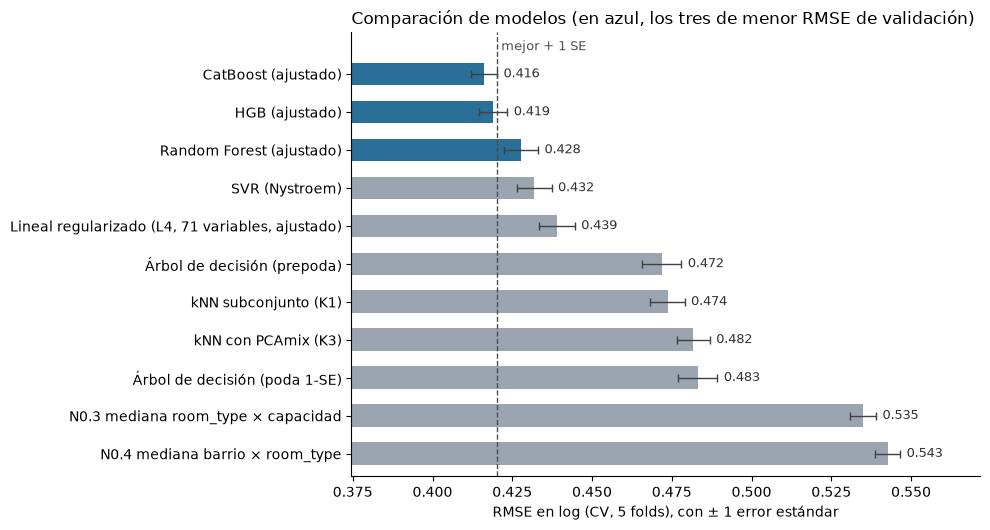

In [42]:
fig, ax = plt.subplots(figsize=(10, 5.4))
orden = comparativa.sort_values('rmse_log_val', ascending=False).reset_index(drop=True)
colores = [COLOR_BASE if m in TRES_MEJORES else COLOR_SECUNDARIO for m in orden['modelo']]
ax.barh(orden['modelo'], orden['rmse_log_val'], xerr=orden['se'], color=colores, height=0.6, capsize=3,
        error_kw={'ecolor': '0.25', 'lw': 1})
# Cada etiqueta empieza donde acaba su barra de error, para que no se pisen
MARGEN_ETIQUETA = 0.002
for y, (valor, se) in enumerate(zip(orden['rmse_log_val'], orden['se'])):
    ax.text(valor + se + MARGEN_ETIQUETA, y, f'{valor:.3f}', va='center', fontsize=9, color='0.2')
umbral = mejor['rmse_log_val'] + mejor['se']
ax.axvline(umbral, color='0.3', ls='--', lw=1)
ax.text(umbral, len(orden) - 0.45, ' mejor + 1 SE', fontsize=9, color='0.3', va='bottom', ha='left')
ax.set_xlim(orden['rmse_log_val'].min() * 0.9, (orden['rmse_log_val'] + orden['se']).max() + 0.025)
ax.set_ylim(-0.6, len(orden) + 0.1)
ax.set_xlabel('RMSE en log (CV, 5 folds), con ± 1 error estándar')
ax.set_title('Comparación de modelos (en azul, los tres de menor RMSE de validación)', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Conclusiones:
**CatBoost ajustado es el modelo elegido (RMSE 0,4160; R² 0,658; MAE $47,6), pero su ventaja sobre HGB ajustado
(0,4191) no es concluyente: está dentro de un error estándar. Los dos *boosting* ganan con claridad al resto, y el
modelo final mejora un 22% a la mejor regla ingenua.**

- **Elegido :** con la regla fijada antes de ver la tabla, el elegido es **CatBoost**: RMSE **0,4160 ± 0,0071**, R² **0,658**, MAE **$47,6**, mediana del error **$21,6** y MAPE **31,4%**.
- **Los tres primeros (en azul en el gráfico):** CatBoost, HGB (0,4191) y RF (0,4278).
- **CatBoost frente a HGB:** Δ = **0,0031**, a favor de CatBoost en **5 de 5 folds**, pero **por debajo
  de un error estándar** (0,0032) y con p = 0,10. La ventaja es consistente en signo y **no es concluyente** en
  tamaño. HGB tiene incluso una mediana del error algo menor ($21,5 frente a $21,6). **CatBoost tarda 124 s por fold y HGB 7,7 s: dieciséis veces más. El resto, claramente por detrás.** 
- **Cuánto vale la complejidad:** el lineal con 71 variables, interpretable con coeficientes, se
  queda a un **5,5%** del mejor (0,4390 frente a 0,4160; MAE $50,5 frente a $47,6). Lo que añaden los *boosting* son
  no linealidades e interacciones; la mayor parte de la señal ya la recoge el modelo aditivo.
- **Diferencia train-validación:** pequeña en el lineal (0,010), en el SVR (0,027) y en los *boosting* (0,06-0,08);
  mayor en RF (0,19), sin que le impida generalizar. En kNN (0,41-0,45) no mide sobreajuste: con
  `weights = 'distance'`, cada anuncio del train es su propio vecino.
- **Aviso:** todos los RMSE de modelos ajustados son algo optimistas (elegidos sobre los mismos folds), y más en
  CatBoost y HGB, que tuvieron las búsquedas más grandes. La cifra honesta del elegido saldrá del test.
- **Para el modelo final:** se evalúa CatBoost. Como HGB queda a menos de 1 SE y es dieciséis veces más rápido, se
  propone llevarlo al test como **contraste declarado**, sin que su resultado pueda cambiar la elección
  (`docs/plan_modelo_final.md`, F1).


### 11.1 Escenario A frente a B: cuánto vale conocer al anfitrión

El escenario A (anfitrión nuevo, sin historial) usa las variables de cada familia sin el bloque B2b: las 79
menos el perfil del anfitrión en HGB, y las del lineal elegido (sección 7.4) sin ese bloque en el lineal. La
diferencia con B es lo que aporta conocer el perfil del anfitrión (D1), con el mismo modelo y los mismos folds.

In [43]:
experimento_lineal_b = MEJOR_RIDGE['experimento']
lineal_b = registro.query('experimento == @experimento_lineal_b')
hgb_a = evaluar_registrado(construir_hgb('HGB_ajustado_escenario_A', PARAMS_HGB, COLS_B_A), train, FOLDS_MODELOS,
                           RUTA_REGISTRO)
lineal_a = evaluar_registrado(lineal_elegido('Lineal_ajustado_escenario_A', VARS_LINEAL_A, MEJOR_RIDGE), train, FOLDS_MODELOS,
                              RUTA_REGISTRO, paralelo=5)
escenarios = pd.DataFrame({
    'HGB': {'rmse_B': hgb_final['rmse_log_val'].mean(), 'rmse_A': hgb_a['rmse_log_val'].mean(),
            'mae_usd_val_B': hgb_final['mae_usd_val'].mean(), 'mae_usd_val_A': hgb_a['mae_usd_val'].mean(),
            **comparar_pareado(hgb_final, hgb_a)},
    'Lineal': {'rmse_B': lineal_b['rmse_log_val'].mean(), 'rmse_A': lineal_a['rmse_log_val'].mean(),
               'mae_usd_val_B': lineal_b['mae_usd_val'].mean(), 'mae_usd_val_A': lineal_a['mae_usd_val'].mean(),
               **comparar_pareado(lineal_b, lineal_a)},
}).T
display(escenarios)

,rmse_B,rmse_A,mae_usd_val_B,mae_usd_val_A,delta_medio,delta_sd,folds_mejora,p_nadeau_bengio,entra
HGB,0.419064,0.434373,48.132751,49.66611,0.015309,0.0035,5/5,0.001428,True
Lineal,0.439021,0.452191,50.508298,51.549737,0.013169,0.002005,5/5,0.000305,True


#### Conclusiones:
**Conocer el perfil del anfitrión mejora la predicción de forma clara y consistente: sin él (escenario A), el
RMSE sube un 3,7% en HGB y un 3,0% en el lineal, unos $1-1,5 más de error medio por noche.**

- **Interpretación:** las dos familias pierden algo parecido, así que el perfil del anfitrión aporta sobre todo
  información **aditiva**: la profesionalización y la cartera desplazan el precio arriba o abajo de forma bastante
  uniforme. HGB pierde algo más porque también aprovecha sus interacciones con el producto y la zona.
- **Limitaciones que se declaran:**  Los hiperparámetros se eligieron en el escenario B y se reutilizan en el A, así que el A parte con una ligera desventaja: la diferencia puede estar algo sobrestimada.
- **Para el sponsor:** un anfitrión nuevo, sin historial, recibe una predicción algo menos precisa (unos $1,5 más
  de error medio), pero el modelo **sigue siendo útil sin su perfil**.


## 12. IMPORTANCIA DE VARIABLES

**Pregunta:** ¿qué información usa cada modelo para predecir el precio, y coinciden las familias?

**Método: importancia por permutación sobre validación** (`func_modelado.importancia_permutacion`). Se ajusta el
modelo en el train del fold y, en su validación, se baraja una variable (o un bloque entero) y se mide cuánto sube
el RMSE en log. Si el modelo no usa esa información, el RMSE no cambia. Se mide en validación y no en train para ver
lo que el modelo **generaliza**, no lo que memoriza.

| Qué | Modelos | Folds | Repeticiones |
|---|---|---|---|
| Por bloques (los de `PreparadorListings.bloques_`) | Todos los de la tabla comparativa salvo las referencias ingenuas | 2 | 5 |
| Variable a variable | El elegido en sección 11 y el lineal | 1 (se reentrena una vez) | 5 |
| Por impureza (MDI, reducción de varianza) | Solo el árbol de decisión, para ilustrar su sesgo | 1 | — |
| Coeficientes anulados | Lasso y ElasticNet de sección 5.1 | 1 | — |

`latitude` y `longitude` se permutan **juntas** (`coordenadas`): cada una por separado no significa nada. Las
columnas de un bloque se permutan con la misma permutación, así que se conserva su relación interna.

**Limitaciones que se declaran:** (1) con variables correlacionadas (coordenadas, distancia al centro, distrito y
barrio) la importancia se reparte entre ellas y cada una parece menos importante que su información conjunta; por eso
se mira también por bloques; (2) permutar crea anuncios irreales (un estudio con cuatro dormitorios); (3) es
importancia **para el modelo**, no un efecto causal sobre el precio. **SHAP** se calcula solo para el modelo final,
en la Fase 10.

Tiempo por modelo (s, ajuste + permutaciones en 2 folds): {'Lineal regularizado (L4, 71 variables, ajustado)': 55, 'kNN subconjunto (K1)': 6, 'kNN con PCAmix (K3)': 37, 'Árbol de decisión (prepoda)': 3, 'Árbol de decisión (poda 1-SE)': 8, 'SVR (Nystroem)': 31, 'Random Forest (ajustado)': 30, 'HGB (ajustado)': 29, 'CatBoost (ajustado)': 342}


grupo,B0_producto,B1_ubicacion,B2a_condiciones,B2b_anfitrion,B3_amenities_comunes
modelo,,,,,
CatBoost (ajustado),0.3072,0.1066,0.0075,0.0549,0.0419
HGB (ajustado),0.3092,0.1021,0.0066,0.0531,0.0379
Random Forest (ajustado),0.3075,0.0984,0.0021,0.0448,0.0297
SVR (Nystroem),0.2669,0.0862,0.0045,0.0507,0.0610
"Lineal regularizado (L4, 71 variables, ajustado)",0.3085,0.0852,0.0060,0.0404,0.0420
Árbol de decisión (prepoda),0.3196,0.0937,0.0016,0.0478,0.0182
kNN subconjunto (K1),0.3108,0.1067,NaN,NaN,NaN
kNN con PCAmix (K3),0.2224,0.0408,-0.0002,0.0200,0.0615
Árbol de decisión (poda 1-SE),0.3221,0.0823,0.0000,0.0383,0.0114


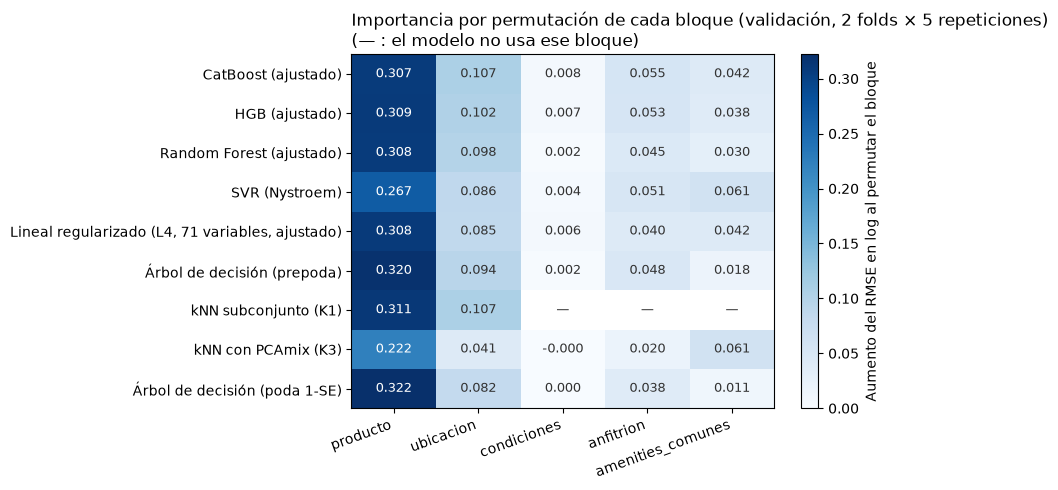

In [44]:
import re
import time

GRUPOS_BLOQUE = {nombre: bloques[nombre] for nombre in ESCALERA_BLOQUES}
GRUPOS_VARIABLE = {'coordenadas': COORDENADAS, **{c: [c] for c in COLS_B if c not in COORDENADAS}}
FOLDS_IMPORTANCIA = FOLDS_MODELOS[:2]
N_REPETICIONES_PERMUTACION = 5

# Cada modelo de la tabla comparativa (salvo las referencias), con sus variables e hiperparametros elegidos
fila_k1 = mejores_knn_por_variante.loc['K1 subconjunto']
fila_mixto = mejores_knn_por_variante.loc[VARIANTE_KNN_MIXTO]
modelos_importancia = {
    ETIQUETA_LINEAL: lineal_elegido(MEJOR_RIDGE['experimento'], VARS_LINEAL, MEJOR_RIDGE),
    'kNN subconjunto (K1)': Experimento(fila_k1['experimento'], make_pipeline(
        preprocesador_lineal(COLS_KNN), KNeighborsRegressor(int(fila_k1['k']), weights=fila_k1['weights'])), COLS_KNN),
    ETIQUETA_KNN_MIXTO: knn_mixto(VARIANTE_KNN_MIXTO, int(fila_mixto['k']), int(fila_mixto['componentes']), VARS_RIDGE),
    'Árbol de decisión (prepoda)': Experimento(mejor_arbol['experimento'], make_pipeline(
        preprocesador_ordinal(COLS_B), DecisionTreeRegressor(max_depth=int(mejor_arbol['max_depth']),
                                                             min_samples_leaf=int(mejor_arbol['min_samples_leaf']),
                                                             random_state=SEMILLA)), COLS_B),
    'Árbol de decisión (poda 1-SE)': Experimento(poda_1se['experimento'], make_pipeline(
        preprocesador_ordinal(COLS_B), DecisionTreeRegressor(ccp_alpha=poda_1se['ccp_alpha'], random_state=SEMILLA)),
        COLS_B),
    'SVR (Nystroem)': construir_svr(MEJOR_SVR['experimento'], MEJOR_SVR['gamma'], MEJOR_SVR['C'], COLS_B),
    'Random Forest (ajustado)': construir_rf('RF_ajustado', PARAMS_RF, COLS_B, n_estimators=500),
    'HGB (ajustado)': construir_hgb('HGB_ajustado', PARAMS_HGB, COLS_B),
    # La permutacion reentrena CatBoost en CPU, como la busqueda
    'CatBoost (ajustado)': construir_catboost('CatBoost_ajustado', PARAMS_CATBOOST, COLS_B, dispositivo='CPU'),
}
assert set(modelos_importancia) == set(comparativa['modelo']) - {'N0.3 mediana room_type × capacidad',
                                                                'N0.4 mediana barrio × room_type'}

tablas_bloque, tiempos = [], {}
for etiqueta, exp in modelos_importancia.items():
    inicio = time.perf_counter()
    tablas_bloque.append(importancia_en_folds(exp, train, FOLDS_IMPORTANCIA, GRUPOS_BLOQUE, N_REPETICIONES_PERMUTACION)
                         .assign(modelo=etiqueta))
    tiempos[etiqueta] = time.perf_counter() - inicio
importancia_bloques = pd.concat(tablas_bloque, ignore_index=True)
importancia_bloques.to_csv(OUTPUT_DIR / 'importancia_bloques.csv', index=False)
print('Tiempo por modelo (s, ajuste + permutaciones en 2 folds):', {k: round(v) for k, v in tiempos.items()})

orden_modelos = [m for m in comparativa['modelo'] if m in modelos_importancia]
resumen_bloques = (importancia_bloques.groupby(['modelo', 'grupo'])['aumento_rmse'].mean().unstack()
                   .reindex(index=orden_modelos, columns=list(GRUPOS_BLOQUE)))
display(resumen_bloques.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
imagen = ax.imshow(resumen_bloques.to_numpy(), cmap='Blues', aspect='auto', vmin=0)
for (i, j), valor in np.ndenumerate(resumen_bloques.to_numpy()):
    texto = '—' if np.isnan(valor) else f'{valor:.3f}'
    color = 'white' if not np.isnan(valor) and valor > np.nanmax(resumen_bloques.to_numpy()) * 0.6 else '0.2'
    ax.text(j, i, texto, ha='center', va='center', fontsize=9, color=color)
ax.set_xticks(range(len(GRUPOS_BLOQUE)), [b.split('_', 1)[1] for b in GRUPOS_BLOQUE], rotation=20, ha='right')
ax.set_yticks(range(len(orden_modelos)), orden_modelos)
fig.colorbar(imagen, ax=ax, label='Aumento del RMSE en log al permutar el bloque')
ax.set_title('Importancia por permutación de cada bloque (validación, 2 folds × 5 repeticiones)\n'
             '(— : el modelo no usa ese bloque)', loc='left')
plt.tight_layout()
plt.show()

CatBoost (ajustado): 142 s


Lineal regularizado (L4, 71 variables, ajustado): 60 s


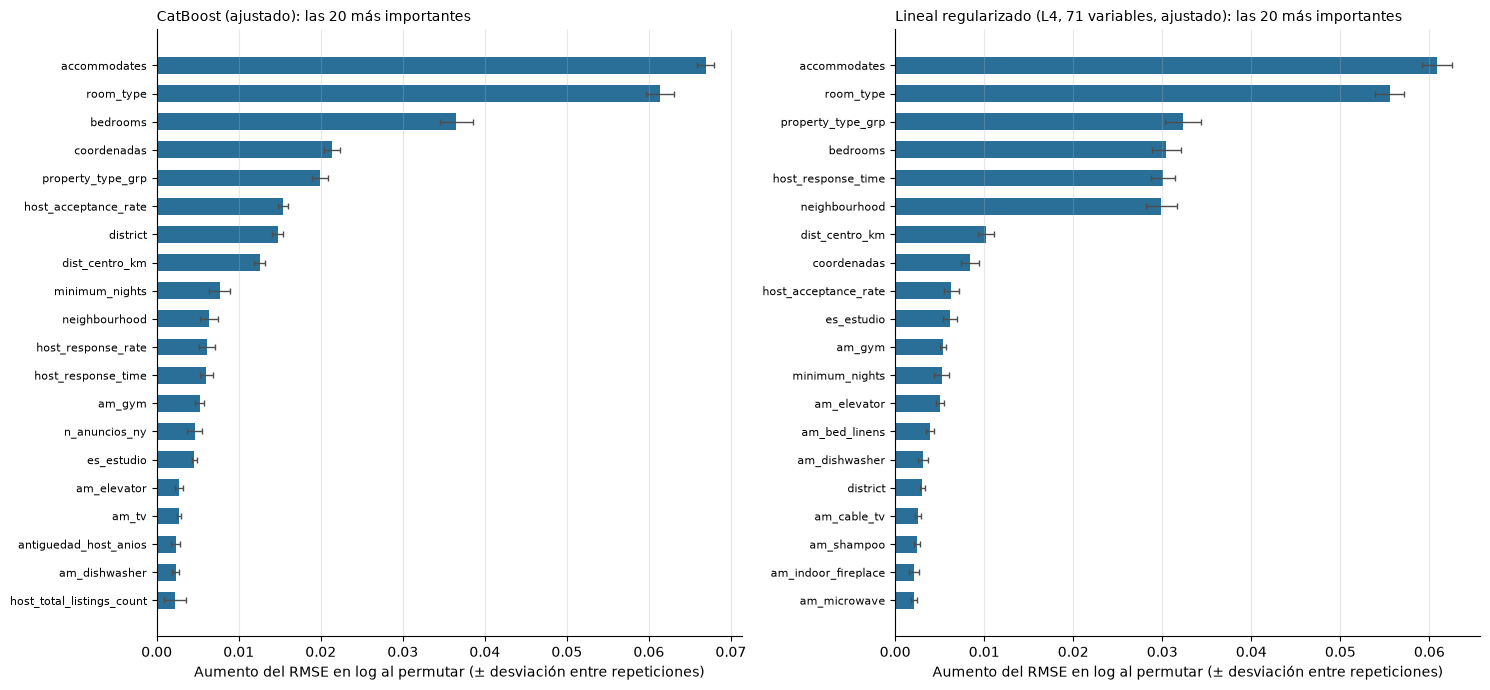

Correlación de Spearman entre las importancias de los dos modelos (70 variables comunes): 0.81
Variables en el top 10 de los dos: accommodates, bedrooms, coordenadas, dist_centro_km, host_acceptance_rate, neighbourhood, property_type_grp, room_type
CatBoost (ajustado): 12 variables con importancia <= 0: am_baking_sheet, am_bbq_grill, am_building_staff, am_ethernet_connection, am_first_aid_kit, am_keypad, am_laundromat_nearby, am_lockbox, am_long_term_stays_allowed, am_luggage_dropoff_allowed, am_oven, am_room_darkening_shades
Lineal regularizado (L4, 71 variables, ajustado): 13 variables con importancia <= 0: am_baking_sheet, am_bbq_grill, am_dishes_and_silverware, am_ethernet_connection, am_hot_water, am_iron, am_keypad, am_lockbox, am_luggage_dropoff_allowed, am_paid_parking_off_premises, am_room_darkening_shades, am_shower_gel, am_single_level_home


In [45]:
# Variable a variable: el modelo elegido y el lineal, reentrenando una vez (primer fold)
modelos_variable = {mejor['modelo']: modelos_importancia[mejor['modelo']], ETIQUETA_LINEAL: modelos_importancia[ETIQUETA_LINEAL]}
tablas_variable = []
for etiqueta, exp in modelos_variable.items():
    inicio = time.perf_counter()
    tablas_variable.append(importancia_en_folds(exp, train, FOLDS_MODELOS[:1], GRUPOS_VARIABLE, N_REPETICIONES_PERMUTACION)
                           .assign(modelo=etiqueta))
    print(f'{etiqueta}: {time.perf_counter() - inicio:.0f} s')
importancia_variables = pd.concat(tablas_variable, ignore_index=True)
importancia_variables.to_csv(OUTPUT_DIR / 'importancia_variables.csv', index=False)
por_variable = importancia_variables.groupby(['grupo', 'modelo'])['aumento_rmse'].mean().unstack()
sd_variable = importancia_variables.groupby(['grupo', 'modelo'])['aumento_rmse'].std().unstack()

fig, ejes = plt.subplots(1, len(modelos_variable), figsize=(15, 7))
for eje, etiqueta in zip(np.atleast_1d(ejes), modelos_variable):
    serie = por_variable[etiqueta].dropna().sort_values().tail(20)
    eje.barh(serie.index, serie.to_numpy(), xerr=sd_variable[etiqueta].reindex(serie.index).to_numpy(),
             color=COLOR_BASE, height=0.6, capsize=2, error_kw={'ecolor': '0.3', 'lw': 1})
    eje.set_title(f'{etiqueta}: las 20 más importantes', loc='left', fontsize=10)
    eje.set_xlabel('Aumento del RMSE en log al permutar (± desviación entre repeticiones)')
    eje.tick_params(axis='y', labelsize=8)
    eje.grid(axis='x', alpha=0.3)
    eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

if len(modelos_variable) == 2:
    comunes = por_variable.dropna()
    a, b = list(modelos_variable)
    top_a, top_b = set(comunes[a].nlargest(10).index), set(comunes[b].nlargest(10).index)
    print(f"Correlación de Spearman entre las importancias de los dos modelos ({len(comunes)} variables comunes): "
          f"{comunes.corr(method='spearman').loc[a, b]:.2f}")
    print(f"Variables en el top 10 de los dos: {', '.join(sorted(top_a & top_b))}")
for etiqueta in modelos_variable:
    nulas = por_variable[etiqueta].dropna()
    nulas = nulas[nulas <= 0].index
    print(f"{etiqueta}: {len(nulas)} variables con importancia <= 0: {', '.join(nulas)}")

In [46]:
# Arbol de decision: importancia por impureza (MDI, reduccion de varianza en train) frente a permutacion (validacion)
f0 = FOLDS_MODELOS[0]
exp_arbol = modelos_importancia['Árbol de decisión (prepoda)']
arbol_f0 = clone(exp_arbol.modelo).fit(train[COLS_B].iloc[f0.train], train[TARGET].iloc[f0.train])
mdi = pd.Series(arbol_f0[-1].feature_importances_, index=arbol_f0[0].get_feature_names_out())
mdi['coordenadas'] = mdi[COORDENADAS].sum()
mdi = mdi.drop(COORDENADAS)
permutacion_arbol = importancia_permutacion(arbol_f0, train[COLS_B].iloc[f0.validacion], train[TARGET].iloc[f0.validacion],
                                            GRUPOS_VARIABLE, N_REPETICIONES_PERMUTACION).groupby('grupo')['aumento_rmse'].mean()
mdi_frente_permutacion = pd.DataFrame({'mdi': mdi, 'permutacion': permutacion_arbol})
mdi_frente_permutacion['puesto_mdi'] = mdi_frente_permutacion['mdi'].rank(ascending=False).astype(int)
mdi_frente_permutacion['puesto_permutacion'] = mdi_frente_permutacion['permutacion'].rank(ascending=False).astype(int)
display(mdi_frente_permutacion.sort_values('mdi', ascending=False).head(15).round(4))
print(f"Spearman MDI frente a permutación: {mdi_frente_permutacion['mdi'].corr(mdi_frente_permutacion['permutacion'], method='spearman'):.2f}")
usadas_sin_valor = mdi_frente_permutacion.query('mdi > 0.001 and permutacion <= 0')
print(f"Con MDI > 0,001 pero sin importancia en validación ({len(usadas_sin_valor)}): {', '.join(usadas_sin_valor.index)}")

,mdi,permutacion,puesto_mdi,puesto_permutacion
room_type,0.5504,0.1801,1,1
coordenadas,0.1270,0.0934,2,2
bedrooms,0.1099,0.0658,3,3
n_anuncios_ny,0.0463,0.0069,4,9
accommodates,0.0399,0.0341,5,4
reputacion_cartera,0.0235,0.0091,6,7
host_response_rate,0.0178,0.0169,7,5
dist_centro_km,0.0146,0.0111,8,6
am_elevator,0.0094,0.0086,9,8
am_gym,0.0088,0.0046,10,11


Spearman MDI frente a permutación: 0.79
Con MDI > 0,001 pero sin importancia en validación (1): host_acceptance_rate


In [47]:
# Lineal: que variables anulan del todo Lasso y ElasticNet (mejor alpha de sección 5.1, primer fold, 79 variables)
en_l5 = mejores_l5.set_index('familia').loc['ElasticNet']
elastic = lineal('tmp', COLS_B, ElasticNet(alpha=en_l5['alpha'], l1_ratio=0.5, max_iter=5000), splines=True,
                 interacciones=True).modelo
elastic.fit(train[COLS_B].iloc[f0.train], train[TARGET].iloc[f0.train])
coef_elastic = pd.Series(elastic[-1].coef_, index=elastic[0][-1].get_feature_names_out())


ceros_lasso, ceros_elastic = set(coef_lasso[coef_lasso == 0].index), set(coef_elastic[coef_elastic == 0].index)
print(f"Columnas a cero: Lasso {len(ceros_lasso)}, ElasticNet {len(ceros_elastic)} de {len(coef_elastic)}; "
      f"en las dos: {len(ceros_lasso & ceros_elastic)}")
fuera_lasso, fuera_elastic = anuladas(coef_lasso, COLS_B), anuladas(coef_elastic, COLS_B)
revisar = sorted(fuera_lasso | fuera_elastic | set(FUERA_RIDGE))
display(pd.DataFrame({
    'lasso_la_anula': [v in fuera_lasso for v in revisar],
    'elasticnet_la_anula': [v in fuera_elastic for v in revisar],
    'D4_ridge_la_quita': [v in FUERA_RIDGE for v in revisar],
    f'permutacion_{mejor["modelo"]}': por_variable[mejor['modelo']].reindex(revisar).to_numpy(),
    'permutacion_lineal': por_variable[ETIQUETA_LINEAL].reindex(revisar).to_numpy(),
}, index=revisar).round(4))

Columnas a cero: Lasso 37, ElasticNet 27 de 163; en las dos: 26


,lasso_la_anula,elasticnet_la_anula,D4_ridge_la_quita,permutacion_CatBoost (ajustado),permutacion_lineal
am_dishes_and_silverware,True,False,False,0.0002,-0.0
antiguedad_host_anios,False,False,True,0.0023,NaN
estancia_min_30,False,False,True,0.0005,NaN
host_identity_verified,False,False,True,0.0002,NaN
host_is_superhost,False,False,True,0.0006,NaN
host_total_listings_count,False,False,True,0.0022,NaN
instant_bookable,False,False,True,0.0008,NaN
n_anuncios_ny,False,False,True,0.0046,NaN
reputacion_cartera,False,False,True,0.0007,NaN


- **Árbol: impureza (MDI) frente a permutación (observado):** las tres primeras coinciden (`room_type`,
  coordenadas y `bedrooms`). Las diferencias están en las variables numéricas del anfitrión: **`n_anuncios_ny`**
  es la 4.ª por MDI y la 9.ª por permutación (0,046 frente a 0,007), **`host_total_listings_count`** la 11.ª
  frente a la 24.ª (permutación 0,0001) y **`host_acceptance_rate`** la 14.ª frente a la 77.ª (permutación ≈ 0).
- **Interpretación (sesgo de la MDI):** la MDI se calcula en el train y premia a las variables continuas con
  muchos puntos de corte posibles: el árbol las usa para afinar hojas y eso cuenta como "importancia" aunque no
  generalice. La permutación, medida en validación, las devuelve a su sitio. Por eso la importancia por impureza
  no se usa para decidir nada en este trabajo.
- **Lasso y ElasticNet (observado):** con su mejor `alpha` (1e-4, una penalización muy débil), **Lasso solo anula
  del todo `am_dishes_and_silverware`** y **ElasticNet ninguna variable completa**; lo que anulan son categorías
  sueltas y bases de *splines* (sección 5.1).
- **Tres criterios que no miden lo mismo (interpretación):** Lasso y ElasticNet conservan las 8 variables que quita
  la regla D4 de Ridge, porque con una penalización tan débil cualquier coeficiente distinto de cero sobrevive. D4
  pregunta otra cosa: si la variable **mejora la predicción fuera de la muestra**. La permutación en CatBoost da
  la razón a D4: esas 8 variables tienen importancia casi nula (≤ 0,0023), salvo **`n_anuncios_ny` (0,0046)**, la más
  útil de las descartadas. `am_dishes_and_silverware`, la única que anula Lasso, tampoco aporta en ningún modelo.
